In [1]:
import kagglehub
import shutil
import os
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import userdata

# 1. Kaggle API 인증 설정 (Colab Secrets 기반)
try:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
except Exception as e:
    print("경고: Colab 비밀번호 설정에서 KAGGLE_USERNAME/KEY를 확인하세요.")

try:
    # 2. 데이터 다운로드 시도
    print("Kaggle 서버에서 실제 데이터를 내려받는 중...")
    path = kagglehub.competition_download('playground-series-s6e7')

    for filename in ['train.csv', 'test.csv', 'sample_submission.csv']:
        src = os.path.join(path, filename)
        if os.path.exists(src):
            shutil.copy(src, f'./{filename}')
    print("✅ 데이터 준비 완료!")
except Exception as e:
    print(f"❌ 다운로드 실패: {e}")
    print("\n--- 해결 방법 ---")
    print("1. https://www.kaggle.com/competitions/playground-series-s6e7/rules 에 접속하여 'Accept Rules'를 클릭하세요.")
    print("2. Colab 왼쪽 열쇠 아이콘(Secrets)에 KAGGLE_USERNAME과 KAGGLE_KEY가 정확히 입력되었는지 확인하세요.")

# 3. 데이터 로드
DATA_DIR = Path("./")
TARGET_COL = "health_condition"
ID_COL = "id"

if os.path.exists(DATA_DIR / "train.csv"):
    train_df = pd.read_csv(DATA_DIR / "train.csv")
    test_df = pd.read_csv(DATA_DIR / "test.csv")
    print(f"실제 데이터 로드 성공: {len(train_df):,} 행")
else:
    print("데이터 파일이 없습니다. 시뮬레이션 데이터로 진행하거나 위 단계를 다시 확인하세요.")

# 피처 리스트 초기화
all_features = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]
num_features = train_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
cat_features = train_df[all_features].select_dtypes(include=["object", "category"]).columns.tolist()

Kaggle 서버에서 실제 데이터를 내려받는 중...


100%|██████████| 22.3M/22.3M [00:02<00:00, 10.1MB/s]

Extracting files...


✅ 데이터 준비 완료!
실제 데이터 로드 성공: 690,088 행


In [2]:
# 데이터 로드 & 타겟 정의

import pandas as pd
import numpy as np
from pathlib import Path

# ==========================================
# 1. 폰트 설치 및 환경 설정
# ==========================================

!apt-get update -qq
!apt-get install fonts-nanum -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np
from pathlib import Path
import os

# 나눔 폰트 설정
fe = fm.FontEntry(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic', 'axes.unicode_minus': False})

DATA_DIR = Path("./")
TARGET_COL = "health_condition"
ID_COL = "id"


# ==========================================
# 2. 데이터 수집 (Data Ingestion)
# ==========================================
try:
    if not os.path.exists(DATA_DIR / "train.csv"):
        print("경고: 실제 파일을 찾을 수 없어 시뮬레이션 데이터를 생성합니다.")
        np.random.seed(42)
        train_df = pd.DataFrame(np.random.rand(100, 9), columns=[f'feat_{i}' for i in range(9)])
        train_df[TARGET_COL] = np.random.choice(['at-risk', 'fit', 'unhealthy'], 100)
        train_df[ID_COL] = range(100)
        test_df = pd.DataFrame(np.random.rand(50, 9), columns=[f'feat_{i}' for i in range(9)])
        test_df[ID_COL] = range(100, 150)
    else:
        train_df = pd.read_csv(DATA_DIR / "train.csv")
        test_df = pd.read_csv(DATA_DIR / "test.csv")

    # ==========================================
    # 3. 동적 특성(Feature) 식별
    # ==========================================
    all_features = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]
    num_features = train_df[all_features].select_dtypes(include=[np.number]).columns.tolist()
    cat_features = train_df[all_features].select_dtypes(include=["object", "category"]).columns.tolist()
    print(f"데이터 로드 완료! 수치형: {len(num_features)}, 범주형: {len(cat_features)}")
except Exception as e:
    print(f"오류 발생: {e}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
데이터 로드 완료! 수치형: 7, 범주형: 6


In [27]:
# ==========================================
# 4. 메모리 최적화 함수
# ==========================================
def optimize_dtypes(df, num_cols, cat_cols, is_train=True):
    """
    수치형 데이터 타입을 다운캐스팅(Downcasting)하고 문자열(object) 타입을
    카테고리(category)형으로 변환하여 메모리 사용량을 최적화합니다.
    """
    df = df.copy()

    # 시각화 및 모델링 속도 향상을 위해 문자열(object)을 카테고리(category) 타입으로 변환
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")

    # RAM 메모리 절약을 위해 수치형 데이터 다운캐스팅
    for col in num_cols:
        if col in df.columns:
            if df[col].dtype == "float64":
                df[col] = pd.to_numeric(df[col], downcast="float")
            elif df[col].dtype == "int64":
                df[col] = pd.to_numeric(df[col], downcast="integer")
    return df

# 최적화 적용
train_df = optimize_dtypes(train_df, num_features, cat_features, is_train=True)
test_df = optimize_dtypes(test_df, num_features, cat_features, is_train=False)

# ==========================================
# 5. 데이터셋 요약 및 무결성 확인
# ==========================================
print(f"학습 데이터 형태(Shape): {train_df.shape} | 테스트 데이터 형태: {test_df.shape}")
print(f"수치형 특성 ({len(num_features)}개): {num_features}")
print(f"범주형 특성 ({len(cat_features)}개): {cat_features}\n")

print("타겟 클래스 분포:")
target_dist = train_df[TARGET_COL].value_counts(normalize=True).map(lambda x: f"{x:.2%}")
print(target_dist)

학습 데이터 형태(Shape): (690088, 15) | 테스트 데이터 형태: (295753, 14)
수치형 특성 (7개): ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
범주형 특성 (6개): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']

타겟 클래스 분포:
health_condition
at-risk      85.87%
unhealthy     8.36%
fit           5.77%
Name: proportion, dtype: object


In [4]:
# 결측치 비율 및 중복 행 확인

import pandas as pd
import numpy as np

# ==========================================
# 2단계: 데이터 무결성 및 결측치 분석
# ==========================================
print("--- 결측치 분석 ---")

def get_missing_report(df, name="데이터셋"):
    """
    결측치 수와 비율을 포함하는 상세한 데이터프레임을 생성합니다.
    """
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    report = pd.DataFrame({
        '결측치 수': missing_count,
        '비율 (%)': missing_pct
    }).sort_values(by='결측치 수', ascending=False)

    print(f"\n{name} 결측치 보고서:")
    if missing_count.sum() == 0:
        print("결측치가 없습니다.")
    else:
        print(report[report['결측치 수'] > 0])
    return report

train_missing = get_missing_report(train_df, "훈련 데이터")
test_missing = get_missing_report(test_df, "테스트 데이터")

# ==========================================
# 중복 행 확인
# ==========================================
print("\n--- 중복 데이터 분석 ---")

# 1. 훈련 데이터 내 완전 중복 행 (타겟 포함)
train_dups = train_df.duplicated().sum()
print(f"훈련 데이터 내 완전 중복 행 수: {train_dups}")

# 2. 피처 공간 내 중복 행 (ID 및 타겟 제외)
features_to_check = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]

train_feat_dups = train_df.duplicated(subset=features_to_check).sum()
test_feat_dups = test_df.duplicated(subset=[col for col in features_to_check if col in test_df.columns]).sum()

print(f"훈련 데이터 피처 공간 내 중복 행 수 (ID/타겟 제외): {train_feat_dups}")
print(f"테스트 데이터 피처 공간 내 중복 행 수 (ID 제외): {test_feat_dups}")

# 3. 중복(Overlap) 확인: 훈련 데이터와 테스트 데이터 간
# 이는 두 데이터셋 양쪽에 동일한 샘플이 존재하는지 식별합니다.
train_features_only = train_df[features_to_check]
test_features_only = test_df[[col for col in features_to_check if col in test_df.columns]]

# 교집합을 찾기 위해 병합
combined_features = pd.concat([train_features_only, test_features_only], axis=0)
total_overlap = combined_features.duplicated().sum() - train_feat_dups - test_feat_dups
print(f"훈련 및 테스트 데이터 간 겹치는 동일한 피처 행 수: {max(0, total_overlap)}")

--- 결측치 분석 ---

훈련 데이터 결측치 보고서:
                         결측치 수     비율 (%)
stress_level             82811  12.000064
sleep_duration           75999  11.012943
sleep_quality            58331   8.452690
calorie_expenditure      52853   7.658878
water_intake             43477   6.300211
physical_activity_level  36621   5.306715
smoking_alcohol          28582   4.141791
gender                   21373   3.097141
step_count               13916   2.016554
bmi                      13898   2.013946
heart_rate                7833   1.135073
diet_type                 6901   1.000017
exercise_duration         6901   1.000017

테스트 데이터 결측치 보고서:
                         결측치 수     비율 (%)
stress_level             35490  11.999878
sleep_duration           32571  11.012906
sleep_quality            24999   8.452662
calorie_expenditure      22652   7.659094
water_intake             18633   6.300190
physical_activity_level  15695   5.306793
smoking_alcohol          12249   4.141632
gender                    

--- 타겟 변수 심층 분석 ---

타겟 클래스 분포 요약:
                      개수     비율 (%)
health_condition                   
at-risk           592561  85.867455
unhealthy          57724   8.364730
fit                39803   5.767815


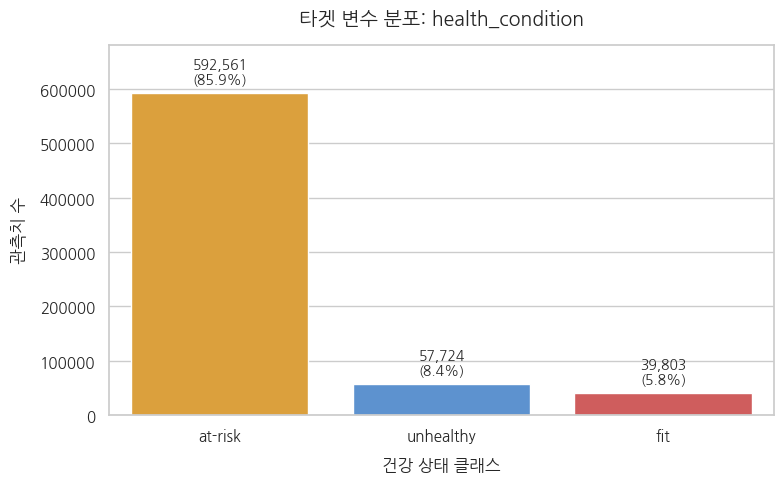

In [9]:
# 타겟 변수 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3단계: 타겟 변수 분석
# ==========================================
print("--- 타겟 변수 심층 분석 ---")

# 1. 절대 빈도 및 상대 빈도(비율) 계산
target_counts = train_df[TARGET_COL].value_counts()
target_pct = train_df[TARGET_COL].value_counts(normalize=True) * 100

target_report = pd.DataFrame({
    '개수': target_counts,
    '비율 (%)': target_pct
})
print("\n타겟 클래스 분포 요약:")
print(target_report)

# 2. 고급 시각화 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 맞춤형 전문 색상 팔레트 생성
colors = ["#4A90E2", "#F5A623", "#E24A4A"]

plt.rcParams['font.family'] = 'NanumGothic'

ax = sns.countplot(
    data=train_df,
    x=TARGET_COL,
    order=target_counts.index,
    palette=colors,
    hue=TARGET_COL,
    legend=False
)

# 3. 막대 상단에 비율 및 개수 동적 주석 달기
total_samples = len(train_df)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_samples) * 100
    ax.annotate(
        f'{int(height):,}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

# 4. 최종 플롯 스타일링
plt.title(f"타겟 변수 분포: {TARGET_COL}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("건강 상태 클래스", fontsize=12, labelpad=10)
plt.ylabel("관측치 수", fontsize=12, labelpad=10)
plt.ylim(0, max(target_counts) * 1.15) # 라벨을 위한 상단 여백 추가
plt.tight_layout()
plt.show()

### **타겟 분포 심층 분석 (Deep Dive)**

**의도:** 학생들의 건강 상태 클래스가 얼마나 균등하게 분포되어 있는지 확인합니다.

**해석:**

* `at-risk` 군이 약 85.9%로 압도적인 다수를 차지하며, `unhealthy`와 `fit`은 각각 약 8.4%, 5.8%에 불과합니다.


* 이는 전형적인 **클래스 불균형(Class Imbalance)** 문제를 보여줍니다.



**모델링 가이드:**

* 단순 정확도(Accuracy)는 기만적일 수 있으므로, 모든 클래스를 동등하게 평가하는 **균형 정확도(Balanced Accuracy)**, **F1-Score (Macro)** 또는 **Log-Loss**를 주요 지표로 삼아야 합니다.


* 데이터 증강(SMOTE)보다는 가중치 조절(`class_weight='balanced'`)이나 각 폴드의 클래스 비율을 훈련 데이터와 동일하게 유지하는 정교한 교차 검증(**Stratified K-Fold**)이 효과적일 것입니다.

--- 수치형 특성 형태 분석 (왜도 및 첨도) ---

왜도 및 첨도 요약:
                     훈련 왜도  훈련 첨도  테스트 왜도  테스트 첨도
특성                                               
sleep_duration      -0.008 -0.114  -0.014  -0.107
heart_rate           0.000 -0.187   0.011  -0.235
bmi                  0.025 -0.028   0.029  -0.026
calorie_expenditure -0.184 -0.063  -0.179  -0.058
step_count          -0.180 -1.115  -0.179  -1.114
exercise_duration   -0.375  0.035  -0.374   0.039
water_intake         0.110  0.494   0.109   0.481

수치형 데이터 분포 시각화 중...


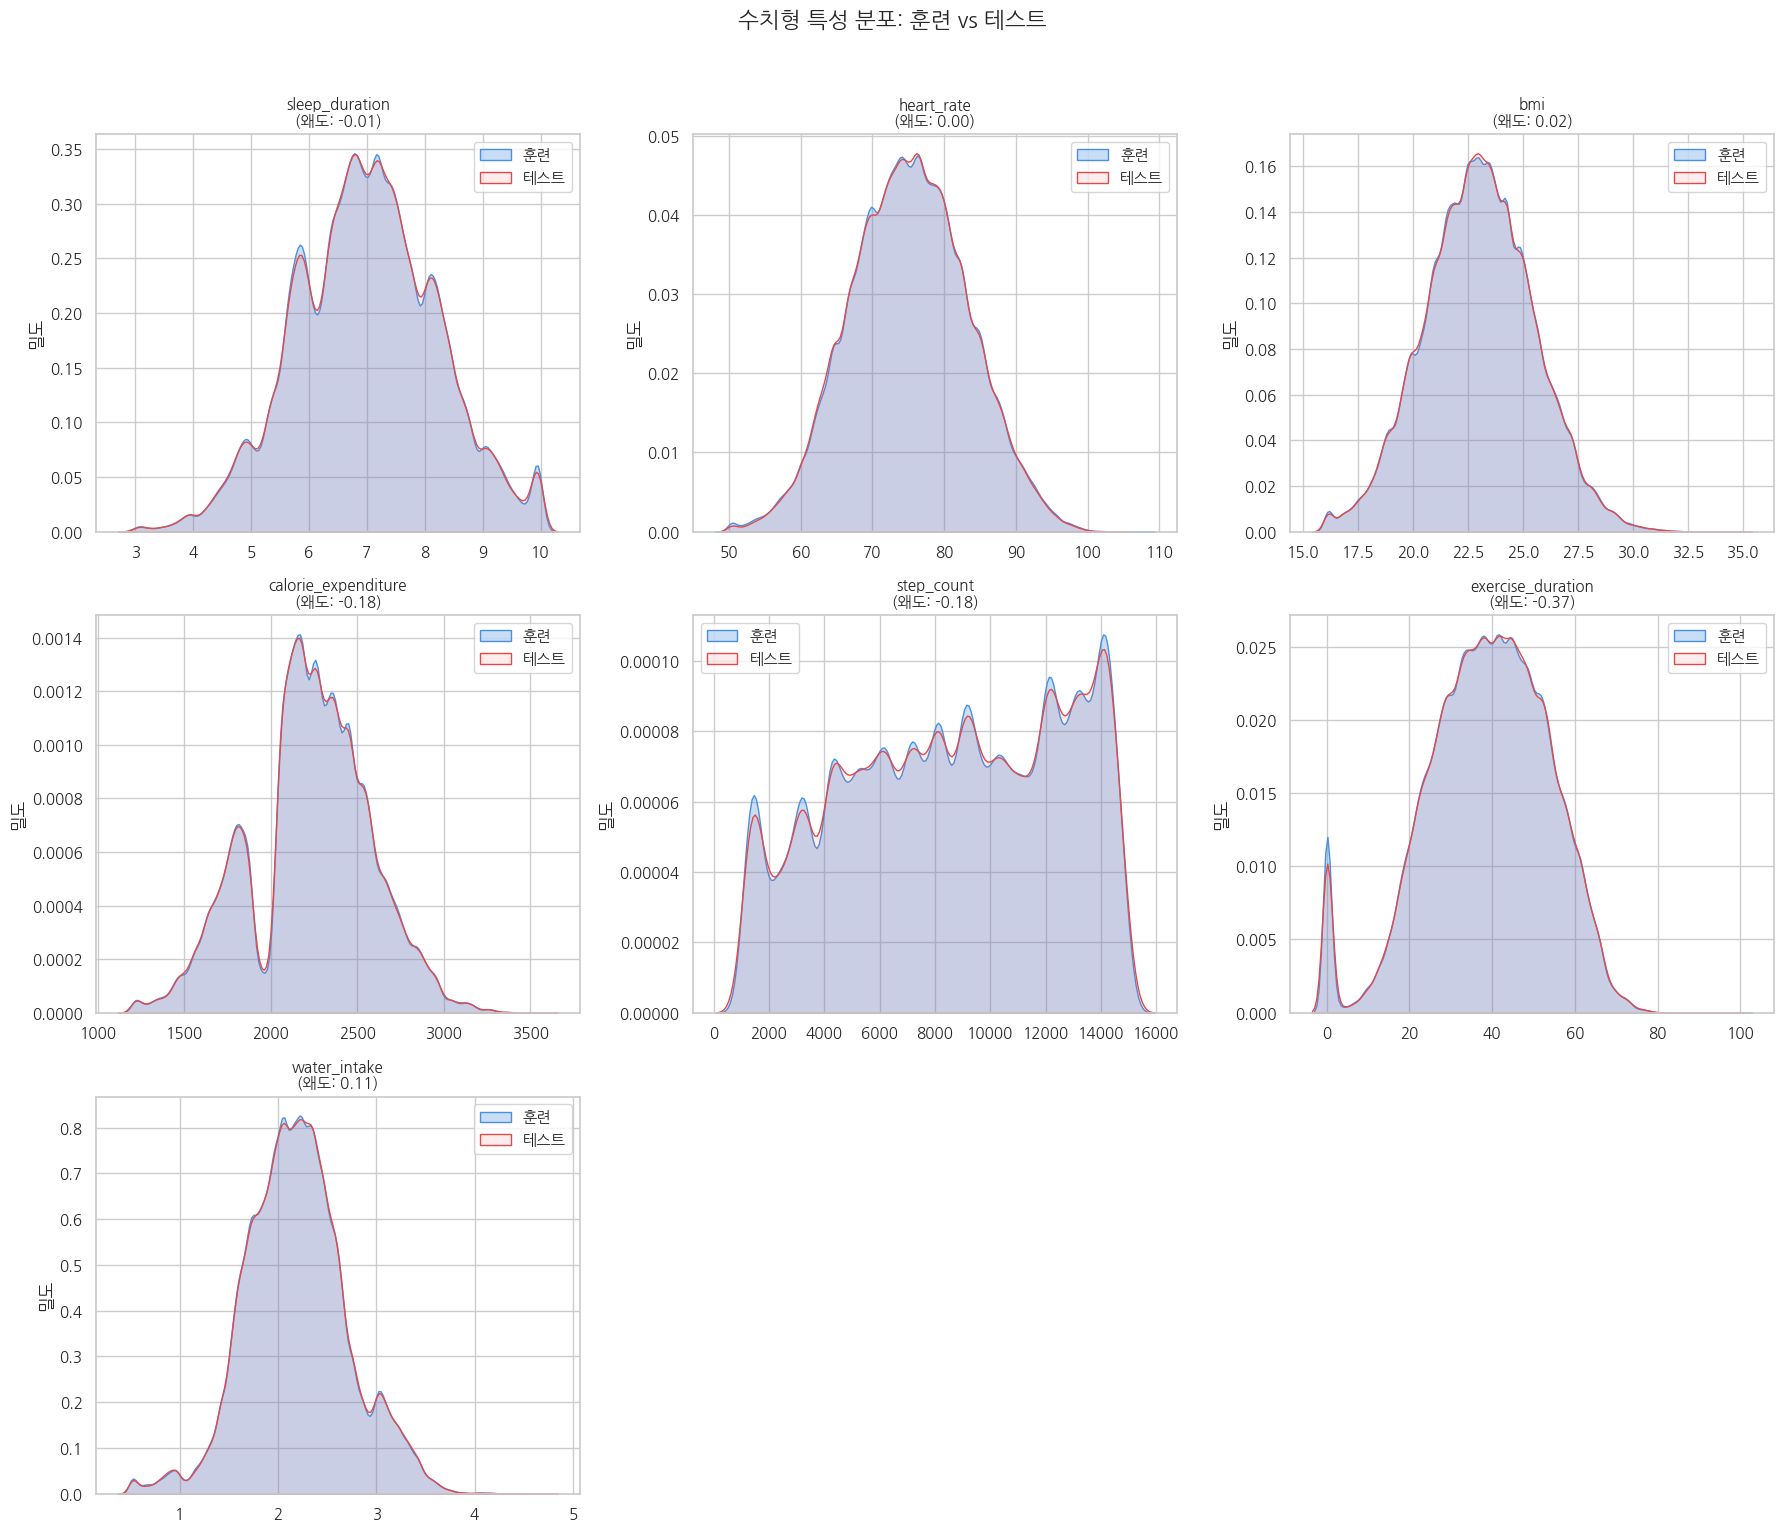


범주형 데이터 분포 시각화 중...


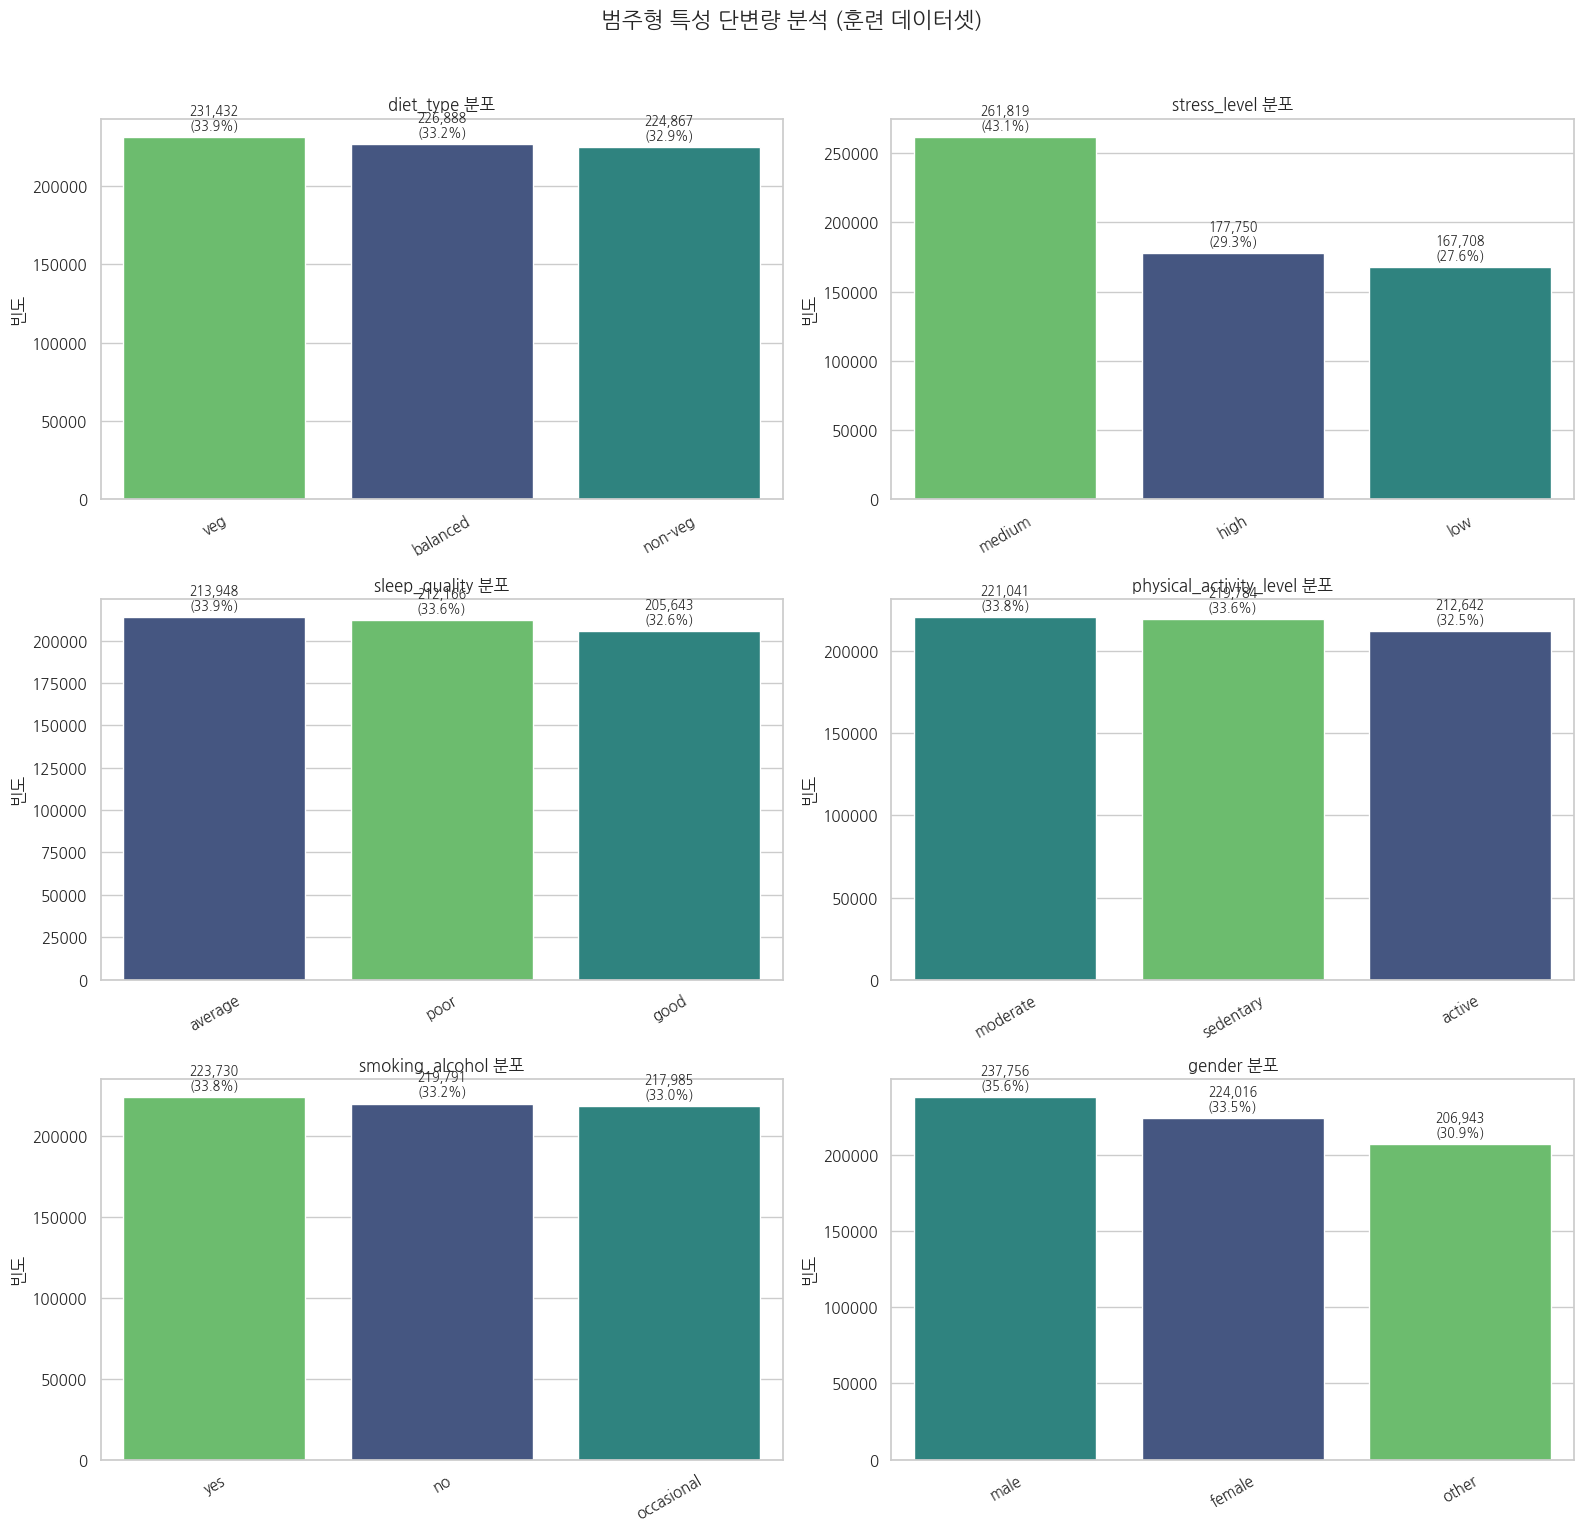

In [10]:
# 단변량 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 4.1단계: 수치형 특성 통계 지표
# ==========================================
print("--- 수치형 특성 형태 분석 (왜도 및 첨도) ---")

shape_metrics = []
for col in num_features:
    # 훈련 데이터의 지표 계산
    train_skew = skew(train_df[col].dropna())
    train_kurt = kurtosis(train_df[col].dropna())

    # 테스트 데이터의 지표 계산
    test_skew = skew(test_df[col].dropna())
    test_kurt = kurtosis(test_df[col].dropna())

    shape_metrics.append({
        '특성': col,
        '훈련 왜도': train_skew,
        '훈련 첨도': train_kurt,
        '테스트 왜도': test_skew,
        '테스트 첨도': test_kurt
    })

shape_df = pd.DataFrame(shape_metrics).set_index('특성')
print("\n왜도 및 첨도 요약:")
print(shape_df.round(3))

# ==========================================
# 4.2단계: 수치형 특성 분포 (훈련 vs 테스트)
# ==========================================
print("\n수치형 데이터 분포 시각화 중...")
num_cols_count = len(num_features)
rows = (num_cols_count + 2) // 3  # 3열 레이아웃을 위한 행 수 동적 계산

fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # 공변량 변화(Covariate shift)를 확인하기 위해 훈련 및 테스트 분포 플롯
    sns.kdeplot(data=train_df, x=col, ax=axes[i], label='훈련', fill=True, alpha=0.3, color='#4A90E2')
    sns.kdeplot(data=test_df, x=col, ax=axes[i], label='테스트', fill=True, alpha=0.1, color='#E24A4A')

    axes[i].set_title(f'{col}\n(왜도: {train_df[col].skew():.2f})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('밀도')
    axes[i].legend()

# 사용하지 않는 축 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("수치형 특성 분포: 훈련 vs 테스트", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# 4.3단계: 범주형 특성 분포
# ==========================================
print("\n범주형 데이터 분포 시각화 중...")
cat_cols_count = len(cat_features)
cat_rows = (cat_cols_count + 1) // 2  # 2열 레이아웃을 위한 행 수 동적 계산

fig, axes = plt.subplots(cat_rows, 2, figsize=(16, 5 * cat_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # 훈련 데이터셋의 빈도순으로 정렬
    order = train_df[col].value_counts().index

    # 시각화를 위한 플롯 생성
    sns.countplot(data=train_df, x=col, order=order, ax=axes[i], palette='viridis', hue=col, legend=False)

    # 막대에 개수 및 비율 동적 주석 달기
    total = len(train_df[col].dropna())
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            percentage = (height / total) * 100
            axes[i].annotate(f'{int(height):,}\n({percentage:.1f}%)',
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=9, fontweight='bold',
                             xytext=(0, 3), textcoords='offset points')

    axes[i].set_title(f'{col} 분포', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('빈도')
    axes[i].tick_params(axis='x', rotation=30)

# 사용하지 않는 축 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("범주형 특성 단변량 분석 (훈련 데이터셋)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **수치형 특성 분포 및 왜도/첨도 분석 (Deep Dive)**

**의도:** 수치형 피처들의 통계적 분포(비대칭성 및 이상치 집중도)를 파악하고, 훈련 및 테스트 데이터 간의 구조적 차이(Data Drift)를 검증합니다.

**해석:**

* `exercise_duration`(-0.375)을 포함한 모든 수치형 피처의 왜도(Skewness)가 0에 가까워, 극단적인 치우침 없이 정규분포에 근사하는 안정적인 형태를 보입니다.
* `step_count`의 첨도(Kurtosis)가 약 -1.11로 다소 평탄한 분포를 띠는 것을 제외하면, 데이터 전반에 극단적인 이상치 꼬리(Heavy-tail)가 존재할 확률이 낮습니다.
* 훈련(Train)과 테스트(Test) 데이터 간의 왜도 및 첨도 수치가 소수점 셋째 자리 수준에서 거의 일치하므로 공변량 변화(Covariate Shift) 위험은 낮아 보입니다.



**모델링 가이드:**

* 왜도 보정을 위한 로그 변환(Log Transformation)이나 Box-Cox 변환 같은 복잡한 전처리 과정은 생략해도 무방합니다.
* 수치형 데이터의 분포가 안정적이므로 단순 Standard Scaling만으로도 선형 모델에 충분합니다.


* 트리 기반 모델(XGBoost, LightGBM)의 경우 별도의 변환 없이도 높은 성능을 기대할 수 있습니다.

수치형 특성 vs 타겟 변수 시각화 중...


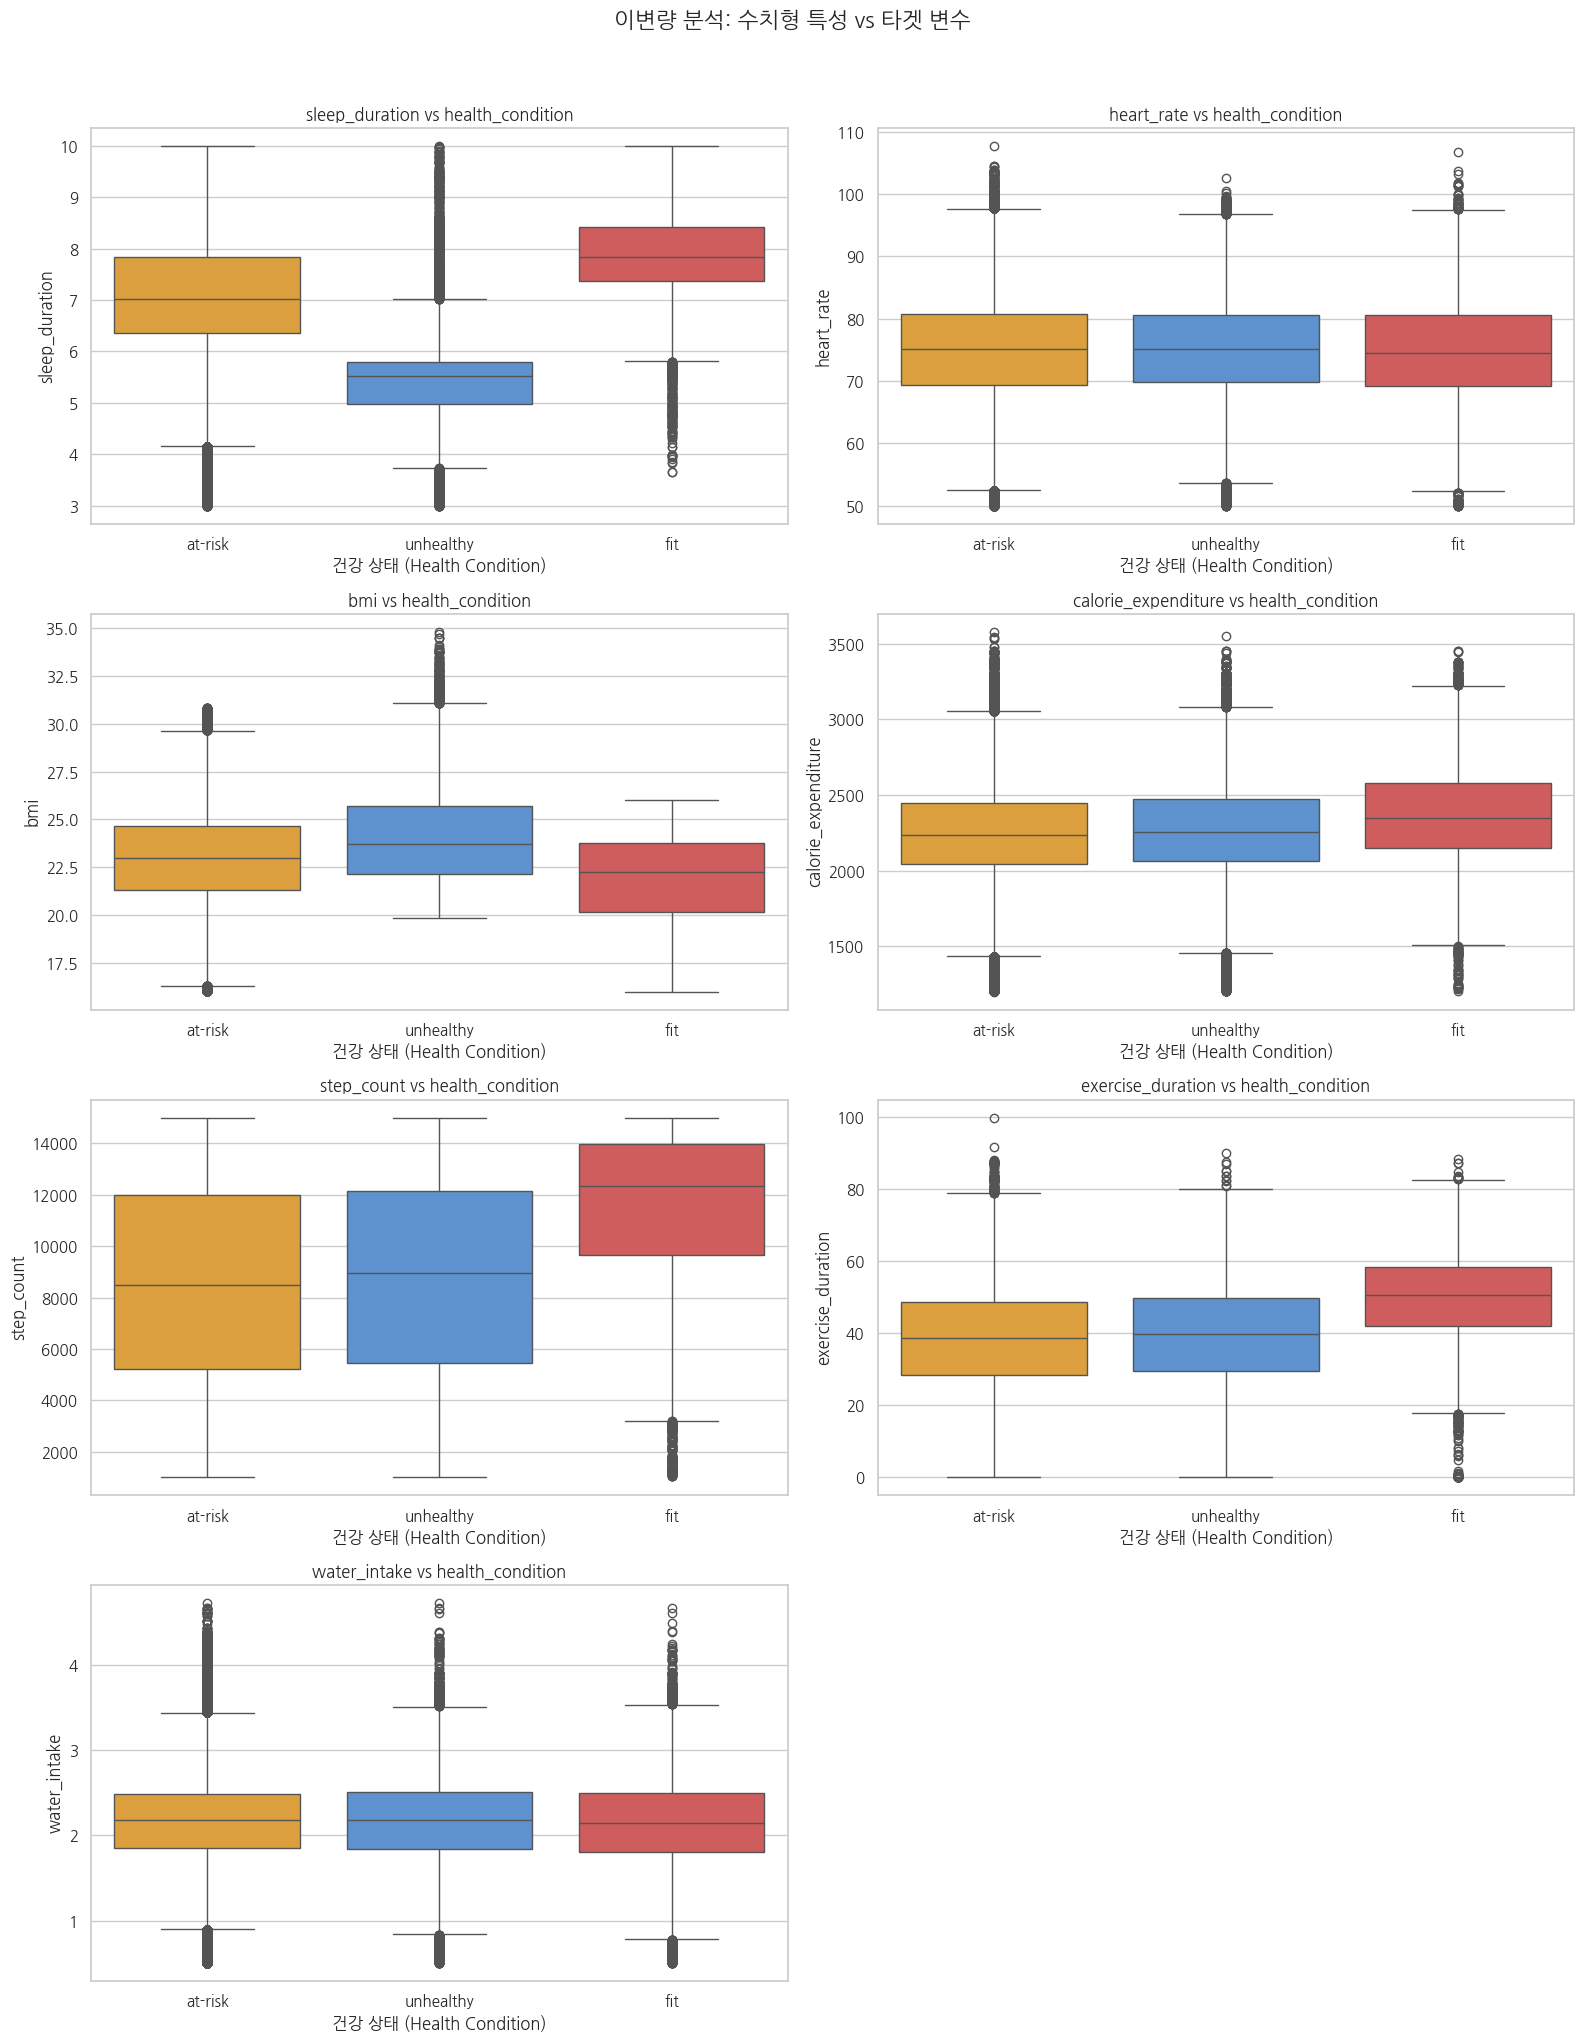


범주형 특성 vs 타겟 변수 시각화 중...


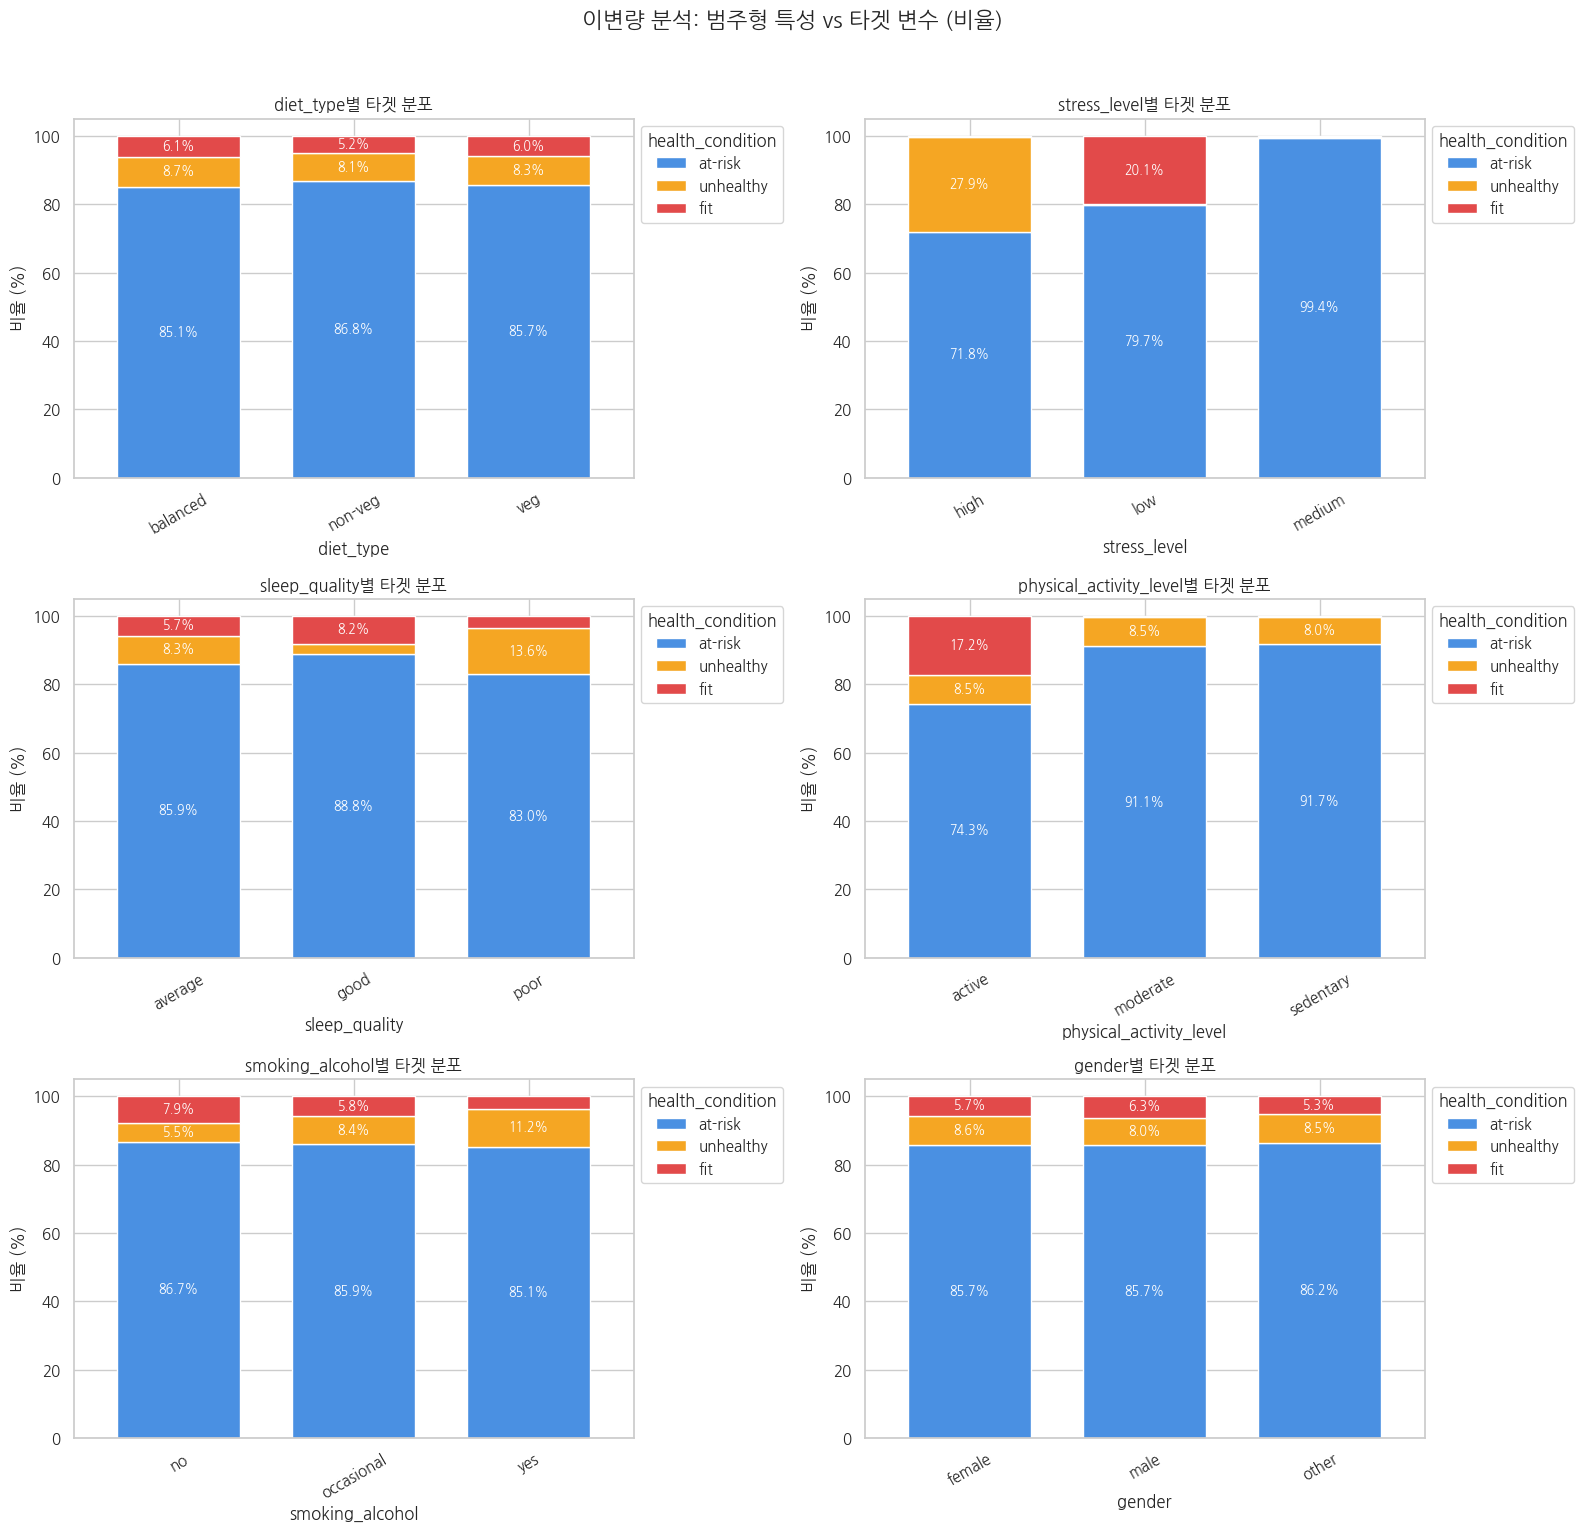

In [11]:
# 이변량 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 올바른 플롯 정렬 순서를 위해 타겟을 문자열(object)/카테고리(category)로 처리
target_order = train_df[TARGET_COL].value_counts().index.tolist()
colors = ["#4A90E2", "#F5A623", "#E24A4A"] # 타겟 클래스에 대해 일관된 색상 팔레트 사용

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 5.1단계: 수치형 특성 vs 타겟 변수 (박스플롯)
# ==========================================
print("수치형 특성 vs 타겟 변수 시각화 중...")
num_cols_count = len(num_features)
rows = (num_cols_count + 1) // 2 # 박스플롯의 가독성을 높이기 위한 2열 레이아웃

fig, axes = plt.subplots(rows, 2, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # 클래스별 데이터 밀도와 이상치를 확인하기 위한 박스플롯 생성
    sns.boxplot(
        data=train_df,
        x=TARGET_COL,
        y=col,
        order=target_order,
        palette=colors,
        ax=axes[i],
        hue=TARGET_COL,
        legend=False
    )

    axes[i].set_title(f'{col} vs {TARGET_COL}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('건강 상태 (Health Condition)')
    axes[i].set_ylabel(col)

# 사용하지 않는 축 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("이변량 분석: 수치형 특성 vs 타겟 변수", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# 5.2단계: 범주형 특성 vs 타겟 변수 (100% 누적 막대그래프)
# ==========================================
print("\n범주형 특성 vs 타겟 변수 시각화 중...")
cat_cols_count = len(cat_features)
cat_rows = (cat_cols_count + 1) // 2 # 2열 레이아웃

fig, axes = plt.subplots(cat_rows, 2, figsize=(16, 5 * cat_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # 클래스 간 비율을 보여주는 교차 집계표(분할표) 생성
    crosstab = pd.crosstab(train_df[col], train_df[TARGET_COL], normalize='index') * 100
    # 표준 타겟 순서와 일치하도록 열 재정렬
    crosstab = crosstab.reindex(columns=target_order)

    # 100% 누적 막대그래프 생성
    crosstab.plot(
        kind='bar',
        stacked=True,
        color=colors,
        ax=axes[i],
        width=0.7
    )

    # 정보 밀도를 높이기 위해 막대 내부에 비율 주석 달기
    for p in axes[i].patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if height > 5: # 텍스트가 들어갈 만큼 충분히 큰 영역에만 주석 추가
            axes[i].annotate(
                f'{height:.1f}%',
                (x + width/2, y + height/2),
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='white'
            )

    axes[i].set_title(f'{col}별 타겟 분포', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('비율 (%)')
    axes[i].legend(title=TARGET_COL, loc='upper left', bbox_to_anchor=(1, 1))
    axes[i].tick_params(axis='x', rotation=30)

# 사용하지 않는 축 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("이변량 분석: 범주형 특성 vs 타겟 변수 (비율)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **이변량 분석 (Deep Dive)**

**의도:** 수치형 및 범주형 피처가 타겟 클래스('`fit`', '`unhealthy`', '`at-risk`')를 분류하는 데 얼마나 유의미한 식별력(Discriminative power)을 가지는지 파악합니다.

**해석:**

* **강력한 수치형 식별자:** `sleep_duration`, `step_count`, `exercise_duration` 피처는 클래스 간 뚜렷한 분포 차이를 보입니다. 'fit' 그룹은 수면 시간(중앙값 약 8시간)과 걸음 수, 운동 시간이 확연히 높으며, 'unhealthy' 그룹은 수면 시간이 눈에 띄게 짧습니다.
* **무의미한 수치형 노이즈:** 반면 `heart_rate`와 `water_intake`는 타겟 클래스 간 박스플롯의 분포(중앙값, 사분위수)가 거의 완전히 겹쳐 있어 분류에 큰 도움이 되지 않습니다.
* **결정적인 범주형 패턴:** `stress_level`과 `physical_activity_level`의 변별력이 압도적입니다. `stress_level`이 'medium'인 경우 거의 100% 'at-risk'로 분류되며, 'high'는 'unhealthy'(27.9%)의 비율을, 'low'는 'fit'(20.1%)의 비율을 폭발적으로 높입니다.
* **영향력이 적은 범주형 피처:** `diet_type`과 `gender`는 범주가 변하더라도 타겟 클래스 구성 비율(at-risk 약 85~86%)이 기준선(Baseline)과 동일하게 유지되어 분류에 기여하는 바가 적습니다.

**모델링 가이드:**

* **핵심 피처 집중:** 트리 기반 앙상블 모델(LightGBM, XGBoost) 학습 시 `sleep_duration`, `step_count`, `stress_level` 등이 상위 분기(Split)를 결정하는 중요 피처(Feature Importance)로 작용할 것입니다.
* **피처 엔지니어링 (Feature Engineering):** 'medium stress'처럼 특정 타겟에 완벽하게 매핑되는 범주형 값은 이진 플래그(Binary Flag) 변수로 파생시켜 모델이 더 쉽게 규칙을 찾도록 도울 수 있습니다.
* **노이즈 피처 제거 (Pruning):** `heart_rate`, `water_intake`, `gender`처럼 변별력이 없는 피처들은 오히려 트리의 분기를 복잡하게 만들고 과적합을 유발할 수 있습니다. 해당 피처들을 제거(Drop)한 뒤 OOF CV 점수가 상승하는지 확인하는 소거법(Ablation Study) 테스트를 적극 권장합니다.

# Phi-K($\phi_K$)

Phi-K($\phi_K$)는 범주형, 연속형, 순서형 변수가 혼합된 데이터셋에서 변수 간의 비선형적 관계까지 일관되게 측정할 수 있는 실용적인 상관계수입니다.

**주요 특징**

* 범주형(성별, 혈액형)과 연속형(나이, 소득) 등 서로 다른 타입의 변수 간 상관관계를 별도의 복잡한 인코딩 과정 없이 하나의 지표로 계산할 수 있습니다.
* 피어슨 카이제곱($\chi^2$) 검정을 기반으로 수학적 기초를 두며, 계산된 결과값은 0(상관관계 전혀 없음)에서 1(완벽한 종속 관계) 사이의 값을 가집니다.
* 단순한 직선 형태의 선형 관계뿐만 아니라, U자형 곡선이나 복잡하게 얽힌 비선형 관계까지 효과적으로 잡아냅니다.
* 이변량 정규 분포(Bivariate normal distribution)를 따르는 두 연속형 변수 사이에서는 피어슨 상관계수와 수학적으로 매우 유사한 값을 도출합니다.

**기존 상관계수와의 핵심 차이**

* **피어슨(Pearson):** 오직 두 연속형 변수 간의 '선형 관계'만 측정할 수 있어 복잡한 패턴을 놓치기 쉽습니다.
* **스피어먼(Spearman):** 변수들의 순위를 기반으로 단조(monotonic) 관계만 측정합니다.
* **크래머의 V(Cramér's V):** 범주형 변수 간의 관계만 측정하며, 데이터 샘플 수가 적거나 범주가 많을 때 값이 과대평가되는 한계가 있습니다. Phi-K는 이러한 통계적 노이즈를 자체적으로 보정(Bias correction)하여 더 신뢰할 수 있는 페널티화된 값을 제공합니다.

**실무 활용 가이드**

* 머신러닝 모델링 전 탐색적 데이터 분석(EDA)을 진행할 때, 데이터 타입이 혼재된 테이블에서 타겟 변수와 가장 연관성이 높은 피처를 찾아낼 때 유용합니다.
* 모델의 성능을 저하시킬 수 있는 피처 간의 다중공선성(Multi-collinearity)을 파악하는 데 강력한 도구로 활용됩니다.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 3.2 MB/s eta 0:00:00
Phi-K (\phi_k) 상관관계 행렬 계산 중...
데이터셋이 큽니다. 빠른 처리를 위해 50,000개의 행을 샘플링합니다.
interval columns not set, guessing: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Phi-K 기준 타겟(health_condition)과 상관관계가 높은 주요 특성:
stress_level               0.756
physical_activity_level    0.558
sleep_duration             0.539
sleep_quality              0.347
bmi                        0.292
smoking_alcohol            0.244
exercise_duration          0.239
step_count                 0.237
calorie_expenditure        0.124
diet_type                  0.046
gender                     0.033
heart_rate                 0.029
water_intake               0.009
Name: health_condition, dtype: float64


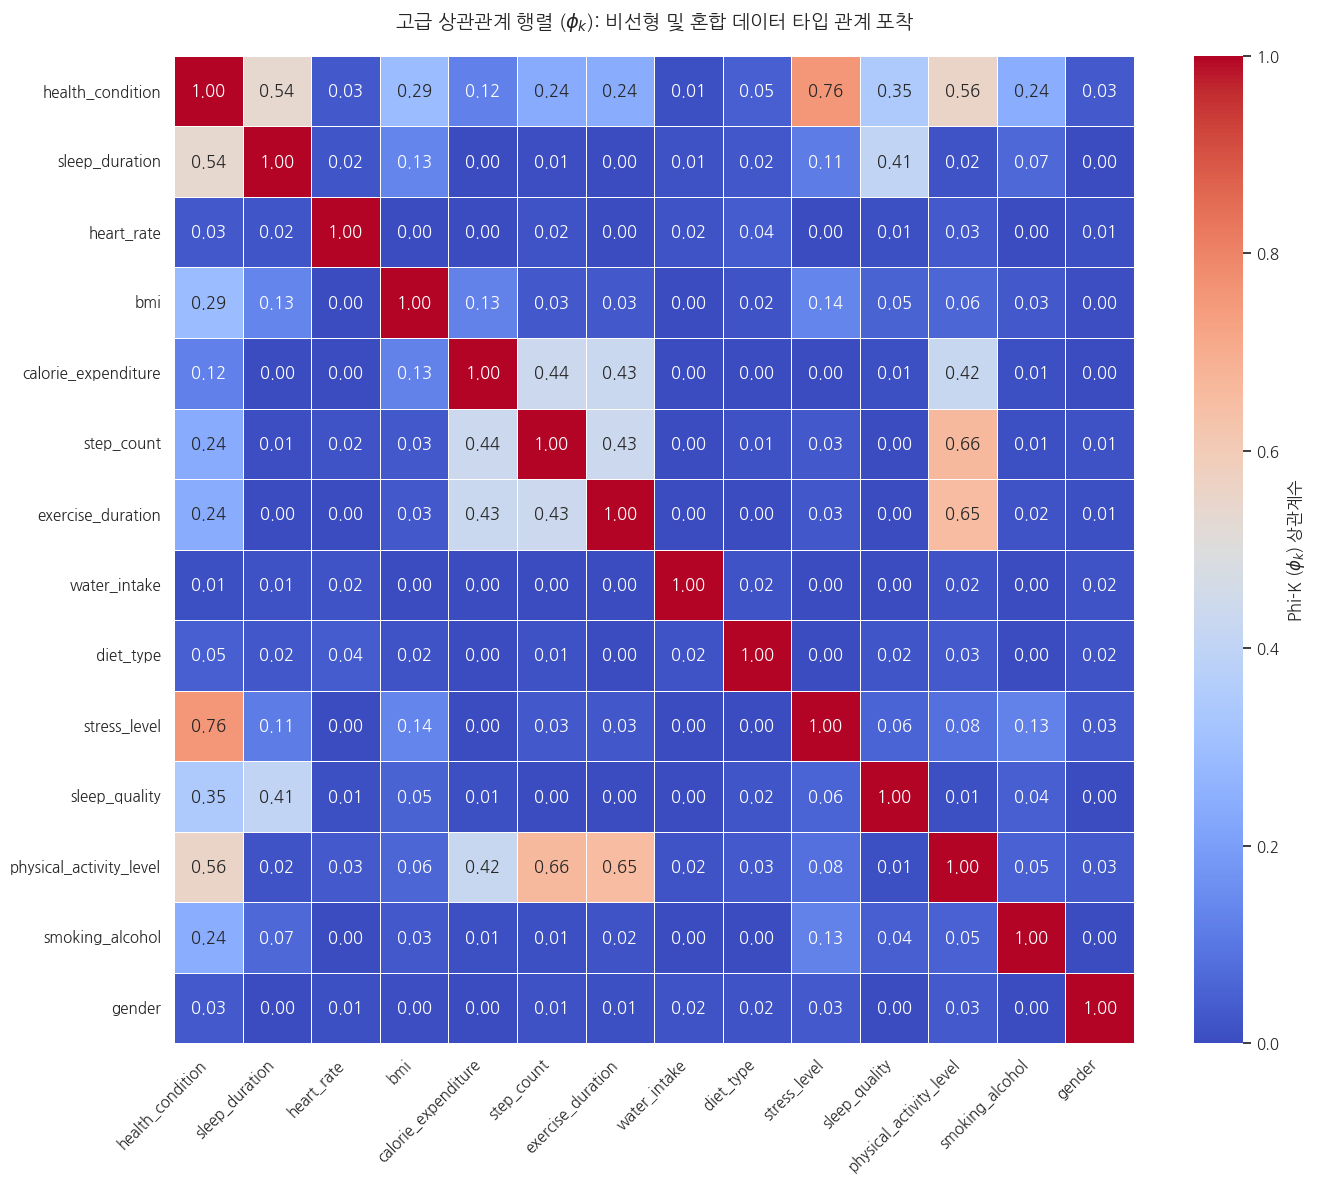

수치형 특성에 대한 스피어먼 순위 상관관계 행렬 계산 중...


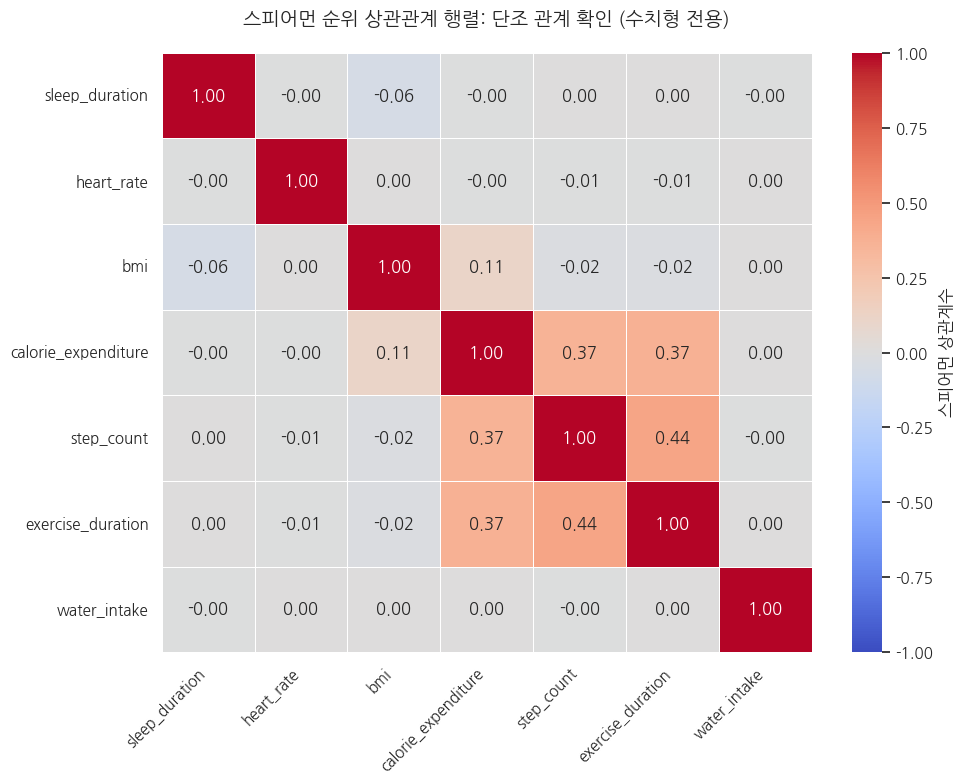


--- 상관관계 인사이트 및 비교 ---
1. 범주형 속성(예: diet_type, stress_level)과 health_condition 타겟 간의 강력한 연관성을 파악하려면 위의 Phi-K 행렬을 확인하십시오.
2. 수치형 열에 대해 Phi-K와 Spearman 결과를 비교하십시오. 특정 특성 쌍이 높은 Phi-K 점수를 가지지만 Spearman 점수가 낮다면, 이는 비선형 모델이나 명시적인 피처 엔지니어링이 필요한 강력한 비선형 관계를 의미합니다.


In [12]:
!pip install phik -q
# Phi-K 상관관계 분석 및 스피어먼(Spearman) 상관관계

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 6단계: 고급 상관관계 분석 (Phi-K 계수)
# ==========================================
print(r"Phi-K (\phi_k) 상관관계 행렬 계산 중...")

# 1. 상관관계 행렬에서 노이즈를 유발할 수 있으므로 ID 열 제거
features_for_corr = train_df.drop(columns=[ID_COL])

# 2. 데이터셋이 매우 큰 경우 실행 시간 최적화를 위해 샘플링 진행
if len(features_for_corr) > 50000:
    print("데이터셋이 큽니다. 빠른 처리를 위해 50,000개의 행을 샘플링합니다.")
    corr_sample = features_for_corr.sample(n=50000, random_state=42)
else:
    corr_sample = features_for_corr

# 3. Phi-K 상관관계 행렬 계산
phik_matrix = corr_sample.phik_matrix()

# 4. 타겟 변수와 가장 상관관계가 높은 특성 추출
target_corr = phik_matrix[TARGET_COL].sort_values(ascending=False).drop(TARGET_COL)
print("\nPhi-K 기준 타겟(health_condition)과 상관관계가 높은 주요 특성:")
print(target_corr.round(3))

# 5. 전체 상관관계 히트맵 시각화
plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": r"Phi-K ($\phi_k$) 상관계수"}
)

plt.title(r"고급 상관관계 행렬 ($\phi_k$): 비선형 및 혼합 데이터 타입 관계 포착", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 6.2단계: 스피어먼 순위 상관관계 (수치형 데이터 전용)
# ==========================================
print("수치형 특성에 대한 스피어먼 순위 상관관계 행렬 계산 중...")

# 연속형 변수에 대한 스피어먼 상관관계 계산
spearman_matrix = train_df[num_features].corr(method='spearman')

# 스피어먼 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "스피어먼 상관계수"}
)

plt.title("스피어먼 순위 상관관계 행렬: 단조 관계 확인 (수치형 전용)", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 6.3단계: 비교 분석 보고서
# ==========================================
print("\n--- 상관관계 인사이트 및 비교 ---")
print("1. 범주형 속성(예: diet_type, stress_level)과 health_condition 타겟 간의 강력한 연관성을 파악하려면 위의 Phi-K 행렬을 확인하십시오.")
print("2. 수치형 열에 대해 Phi-K와 Spearman 결과를 비교하십시오. 특정 특성 쌍이 높은 Phi-K 점수를 가지지만 Spearman 점수가 낮다면, 이는 비선형 모델이나 명시적인 피처 엔지니어링이 필요한 강력한 비선형 관계를 의미합니다.")

### **상관관계 및 의존성 심층 분석 (Deep Dive)**

**의도:** 선형적인 단조 관계(Spearman)뿐만 아니라, 비선형적이고 범주형 변수가 포함된 복잡한 연관성(Phi-K)을 포착하여 모델에 유의미한 피처를 선별합니다.

**해석:**

* **압도적인 타겟 연관성 (Phi-K):** `stress_level`이 타겟 변수와 0.756으로 가장 강력한 연관성을 가집니다. 그 뒤를 `physical_activity_level`(0.558)과 수치형 변수인 `sleep_duration`(0.539)이 잇고 있습니다. 앞선 이변량 분석에서 확인한 강한 식별력이 수치로 정확히 입증되었습니다.
* **수치형 피처의 비선형성:** `sleep_duration`은 타겟과 높은 Phi-K 상관관계(0.539)를 보이지만, 다른 수치형 변수들과의 스피어먼 상관계수는 거의 0에 가깝습니다. 이는 수면 시간이 타겟과 매우 강한 *비선형적* 관계를 맺고 있음을 시사합니다.
* **피처 간 다중공선성 징후:** Phi-K 행렬에서 `step_count`, `exercise_duration`, `physical_activity_level` 세 피처 간의 연관성이 0.65 내외로 상당히 높게 나타납니다. 스피어먼 행렬에서도 `step_count`와 `exercise_duration`이 0.44의 뚜렷한 양의 상관관계를 보입니다.
* **불필요한 노이즈:** `gender`, `heart_rate`, `water_intake`는 타겟 변수는 물론 다른 어떤 피처들과도 유의미한 연관성(Phi-K < 0.04)을 보이지 않아 모델에 기여하지 못하는 노이즈로 작용할 가능성이 큽니다.

**모델링 가이드:**

* **비선형 모델의 필요성:** 타겟과 강한 연관성을 갖는 피처들이 비선형적인 특징을 강하게 띠고 있으므로, 로지스틱 회귀 같은 선형 모델보다는 비선형성을 기본적으로 처리하는 트리 기반 모델(LightGBM, XGBoost)이 훨씬 우수한 성능을 낼 것입니다.
* **특성 선택 (Feature Selection):** 상관관계가 매우 낮은 하위 4개 피처(`diet_type`, `gender`, `heart_rate`, `water_intake`)는 모델의 복잡도만 높이므로 제거하는 것이 성능 향상에 유리합니다.
* **잠재적 다중공선성 주의:** 신체 활동과 관련된 피처 3개(`step_count`, `exercise_duration`, `physical_activity_level`)가 서로 높은 상관성을 띠므로, 선형 모델을 활용한 스태킹(Stacking)이나 블렌딩(Blending) 시 VIF(분산팽창지수) 수치를 점검하여 규제(Ridge, Lasso)를 강하게 걸어주어야 합니다.

IQR(사분위수 범위) 방식을 사용하여 이상치를 계산하는 중...

이상치 탐지 요약 (훈련 vs 테스트):
                     훈련 이상치 수  훈련 이상치 (%)  테스트 이상치 수  테스트 이상치 (%)
특성                                                               
sleep_duration           2020        0.29        869         0.29
heart_rate               2825        0.41       1104         0.37
bmi                      5284        0.77       2256         0.76
calorie_expenditure     12831        1.86       5458         1.85
step_count                  0        0.00          0         0.00
exercise_duration         104        0.02         31         0.01
water_intake            11194        1.62       5237         1.77

이상치 시각화를 위한 훈련 vs 테스트 박스플롯 생성 중...


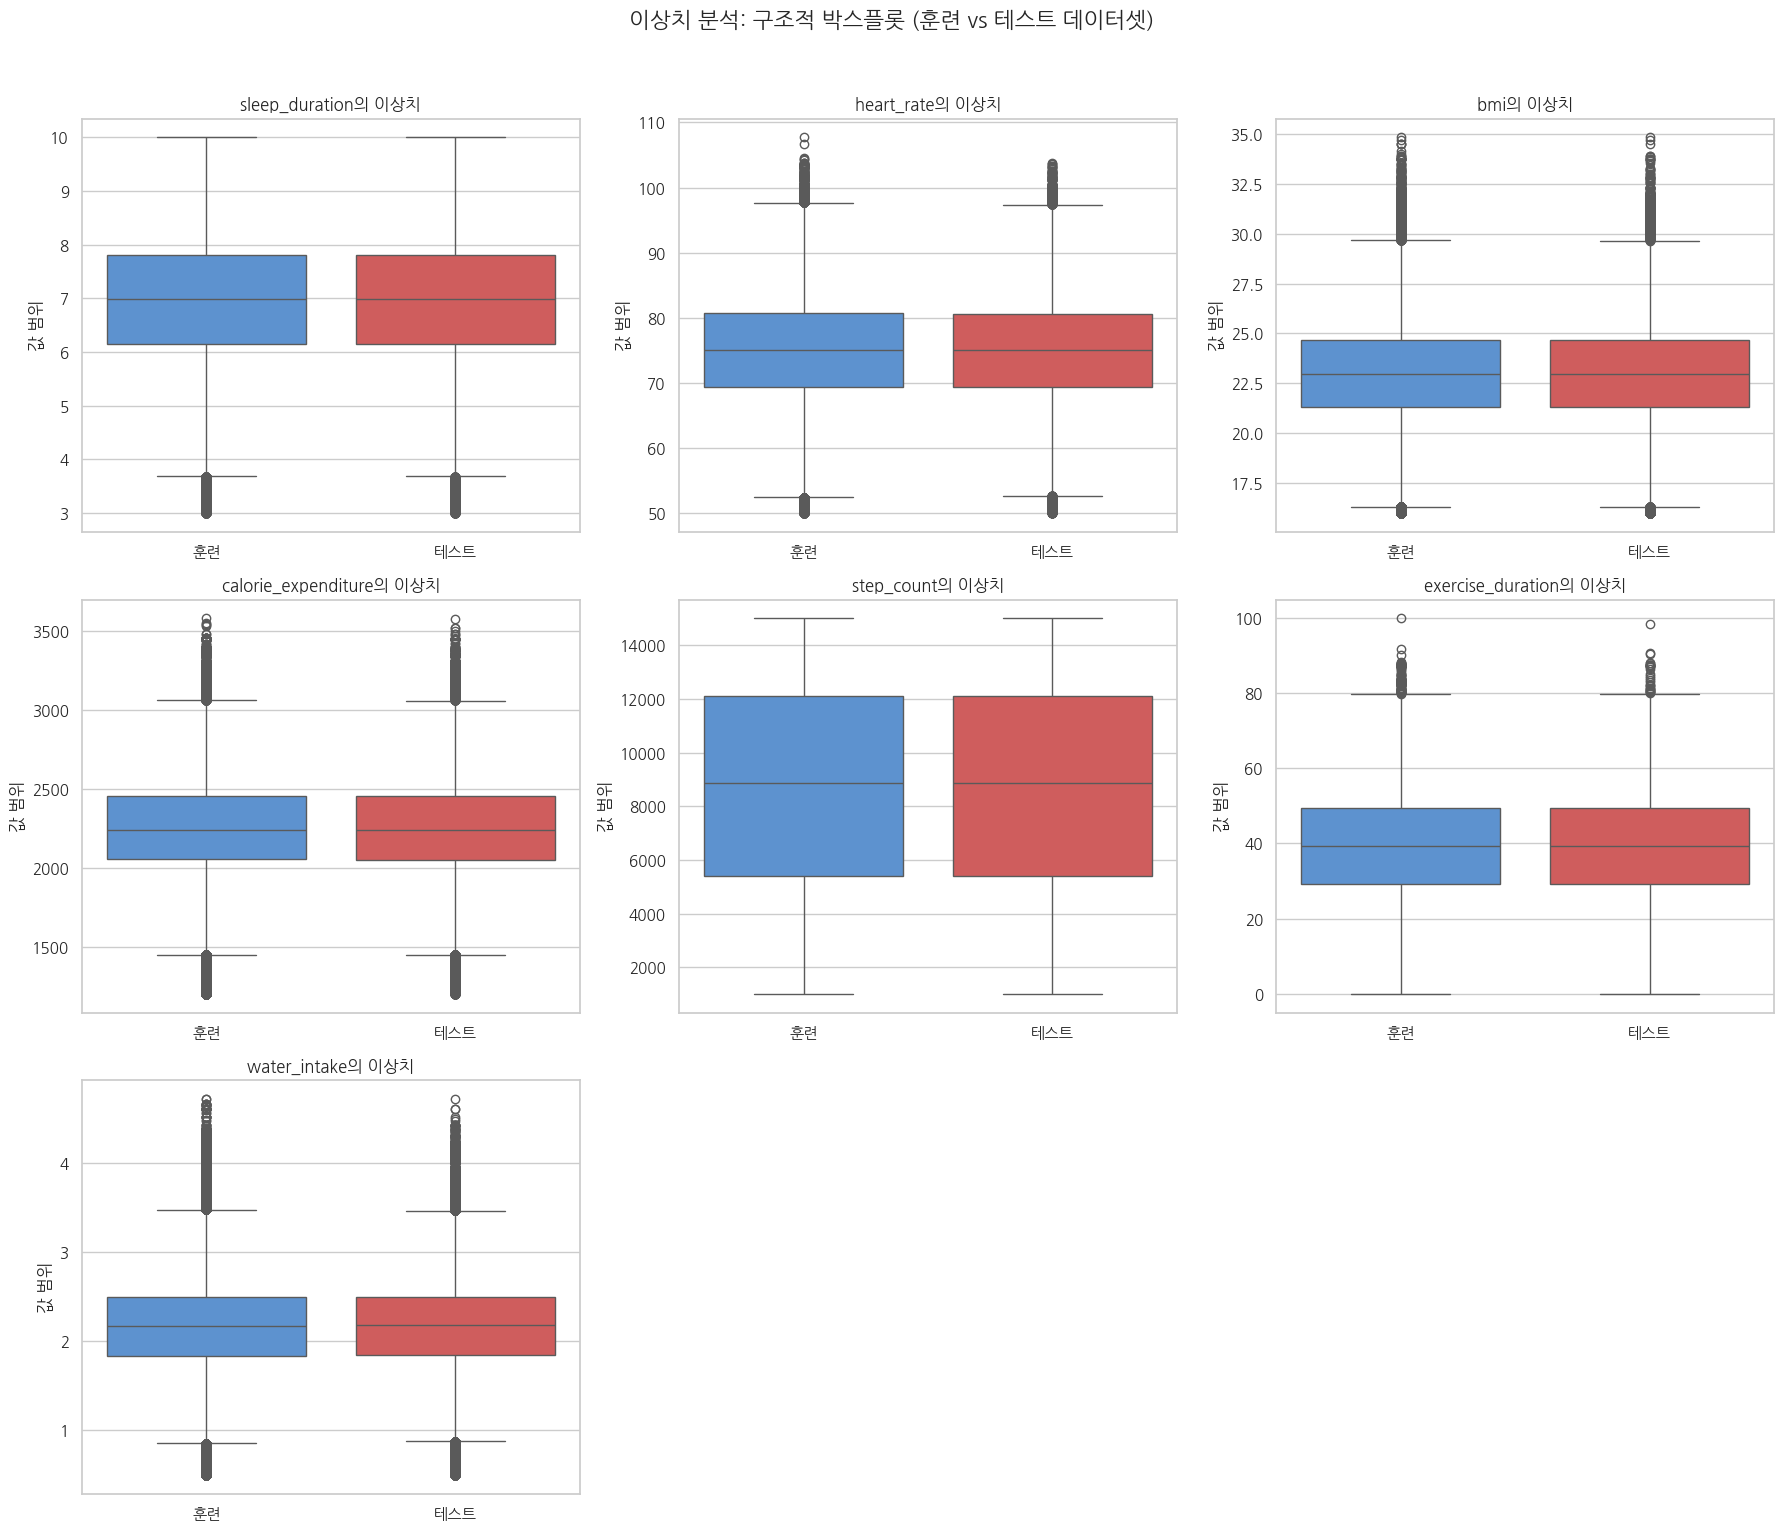

In [13]:
# 이상치 탐지

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 7.1단계: 통계적 이상치 탐지 (IQR 방식)
# ==========================================
print("IQR(사분위수 범위) 방식을 사용하여 이상치를 계산하는 중...")

outlier_report = []

for col in num_features:
    # 훈련 데이터셋 IQR
    q1_train = train_df[col].quantile(0.25)
    q3_train = train_df[col].quantile(0.75)
    iqr_train = q3_train - q1_train
    lower_bound_train = q1_train - 1.5 * iqr_train
    upper_bound_train = q3_train + 1.5 * iqr_train

    outliers_train = train_df[(train_df[col] < lower_bound_train) | (train_df[col] > upper_bound_train)]
    pct_outliers_train = (len(outliers_train) / len(train_df)) * 100

    # 테스트 데이터셋 IQR
    q1_test = test_df[col].quantile(0.25)
    q3_test = test_df[col].quantile(0.75)
    iqr_test = q3_test - q1_test
    lower_bound_test = q1_test - 1.5 * iqr_test
    upper_bound_test = q3_test + 1.5 * iqr_test

    outliers_test = test_df[(test_df[col] < lower_bound_test) | (test_df[col] > upper_bound_test)]
    pct_outliers_test = (len(outliers_test) / len(test_df)) * 100

    outlier_report.append({
        '특성': col,
        '훈련 이상치 수': len(outliers_train),
        '훈련 이상치 (%)': pct_outliers_train,
        '테스트 이상치 수': len(outliers_test),
        '테스트 이상치 (%)': pct_outliers_test
    })

outlier_report_df = pd.DataFrame(outlier_report).set_index('특성')
print("\n이상치 탐지 요약 (훈련 vs 테스트):")
print(outlier_report_df.round(2))

# ==========================================
# 7.2단계: 이상치 시각화 (훈련 vs 테스트 박스플롯) - 수정됨
# ==========================================
print("\n이상치 시각화를 위한 훈련 vs 테스트 박스플롯 생성 중...")

# 나란히 비교하는 플롯 생성을 위해 임시로 데이터셋 병합
train_temp = train_df[num_features].copy()
train_temp['Dataset'] = '훈련'
test_temp = test_df[num_features].copy()
test_temp['Dataset'] = '테스트'

# 수정됨: 중복된 인덱스 라벨로 인해 Seaborn이 중단되는 것을 방지하기 위해 ignore_index=True 추가
combined_df = pd.concat([train_temp, test_temp], axis=0, ignore_index=True)

num_cols_count = len(num_features)
rows = (num_cols_count + 2) // 3

fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
axes = axes.flatten()

# 데이터 출처 비교를 위한 전문적인 색상 테마
dataset_colors = {'훈련': '#4A90E2', '테스트': '#E24A4A'}

for i, col in enumerate(num_features):
    sns.boxplot(
        data=combined_df,
        y=col,
        x='Dataset',
        palette=dataset_colors,
        ax=axes[i],
        hue='Dataset',
        legend=False
    )
    axes[i].set_title(f'{col}의 이상치', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('값 범위')

# 사용하지 않는 축 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("이상치 분석: 구조적 박스플롯 (훈련 vs 테스트 데이터셋)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **이상치 분포 및 구조 분석 (Deep Dive)**

**의도:** IQR(사분위수 범위)을 기준으로 통계적 이상치의 발생 빈도를 파악하고, 훈련 데이터와 테스트 데이터 간의 이상치 패턴이 동일하게 유지되는지(데이터 분포의 동질성)를 검증합니다.

**해석:**

* **극히 낮은 이상치 비율:** `step_count`는 이상치가 전혀 발견되지 않았으며(0.00%), `exercise_duration`(0.02%), `sleep_duration`(0.29%) 등 대부분의 피처에서 이상치 비율이 1% 미만으로 매우 낮습니다.
* **통제 가능한 수준의 변동성:** `calorie_expenditure`(약 1.86%)와 `water_intake`(약 1.62~1.77%)에서 상대적으로 이상치가 두드러지게 관측되나, 전체 데이터 규모 대비 2% 미만으로 극단적인 노이즈를 유발할 수준은 아닙니다.
* **훈련-테스트 분포의 완벽한 일치:** 박스플롯 시각화와 통계 요약표 모두에서 훈련 데이터와 테스트 데이터의 이상치 발생 비율 및 범위가 소수점 단위까지 거의 일치합니다. 이는 두 데이터셋이 동일한 생성 패턴을 띠고 있으며, 공변량 변화(Covariate Shift)가 거의 없음을 입증합니다.

**모델링 가이드:**

* **이상치 보존 (No Clipping/Dropping):** 이상치의 비율이 낮고 테스트 데이터에서도 완벽히 동일한 패턴으로 등장하므로, 이상치를 강제로 제거하거나 상하한값으로 자르는(Clipping/Winsorization) 인위적인 전처리는 불필요합니다. 이러한 이상치는 실제 건강 상태를 분류하는 데 유의미한 극단값 정보로 작용할 수 있습니다.
* **알고리즘 적합성:** XGBoost, LightGBM과 같은 트리 기반 앙상블 알고리즘은 분기(Split)를 통해 이상치의 영향을 자연스럽게 격리하므로, 별도의 이상치 스케일링 없이 원본 피처를 그대로 모델 학습에 투입하는 것이 가장 효율적입니다.

학습 데이터와 테스트 데이터 간의 정확히 일치하는 행 누수 확인 중...
테스트 세트의 전체 행 수: 295753
학습 세트에서 테스트 세트로 누수된 동일 특성 행 수: 0
구조적으로 완전히 일치하는 행 누수는 발견되지 않았습니다.

분산이 0인(상수) 특성 또는 완벽하게 분리되는 특성 확인 중...
감지된 상수 특성: []
타겟과 거의 완벽한 상관관계(>= 0.99)를 보이는 특성: []

소프트 누수(Soft Leakage)를 감지하기 위해 최적화된 최근접 이웃 분석 실행 중...
빠른 거리 계산을 위해 테스트 세트에서 5000개 행을 샘플링합니다.
샘플링된 테스트 행과 학습 행 사이의 최소 거리:
평균 최소 거리: 1.0305
표준편차: 0.3151
거리가 매우 가까운(< 0.05) 샘플링 행 개수: 0


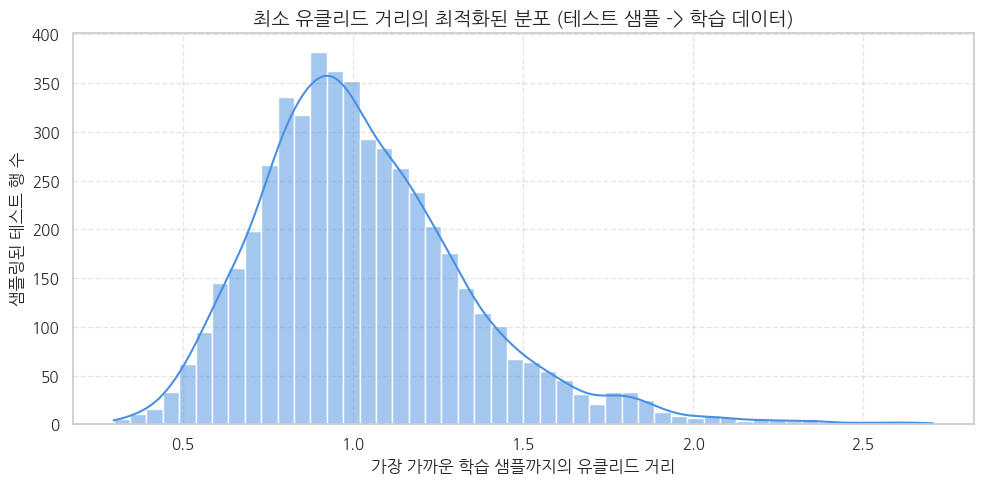

In [14]:
# 데이터 누수(Leakage) 탐지

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 8.1단계: 학습-테스트 데이터 간 동일 행 중복(누수) 확인
# ==========================================
print("학습 데이터와 테스트 데이터 간의 정확히 일치하는 행 누수 확인 중...")

# ID와 Target을 제외한 특성(Feature) 정의
feature_cols = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]

# 구조적 특성 매칭을 위해 타겟과 ID 제외
train_feats = train_df[feature_cols].copy()
test_feats = test_df[feature_cols].copy()

# 테스트 데이터 중 학습 데이터와 정확히 일치하는 행 찾기
merged_overlap = pd.merge(test_feats, train_df[[ID_COL, TARGET_COL] + feature_cols], on=feature_cols, how='inner')

print(f"테스트 세트의 전체 행 수: {len(test_df)}")
print(f"학습 세트에서 테스트 세트로 누수된 동일 특성 행 수: {len(merged_overlap)}")

if len(merged_overlap) > 0:
    print("\n누수된 행 샘플 및 해당 행의 실제 학습 타겟값:")
    print(merged_overlap[[ID_COL, TARGET_COL] + feature_cols[:3]].head())
else:
    print("구조적으로 완전히 일치하는 행 누수는 발견되지 않았습니다.")

# ==========================================
# 8.2단계: 상수 특성 또는 완벽하게 예측하는 특성 확인
# ==========================================
print("\n분산이 0인(상수) 특성 또는 완벽하게 분리되는 특성 확인 중...")

# 단일 값만 갖는 열(상수 특성) 확인
constant_features = [col for col in train_df.columns if train_df[col].nunique() <= 1]
print(f"감지된 상수 특성: {constant_features}")

# 타겟과의 Phik 상관계수가 1.0에 가까운 특성이 있는지 확인 (이전 단계 변수 활용)
try:
    perfect_features = target_corr[target_corr >= 0.99].index.tolist()
    print(f"타겟과 거의 완벽한 상관관계(>= 0.99)를 보이는 특성: {perfect_features}")
except NameError:
    print("메모리에서 Phik 상관계수 행렬을 찾을 수 없습니다. 상관관계 누수 검사를 건너뜁니다.")

# ==========================================
# 8.3단계: 최근접 이웃(Nearest Neighbors) 기반 유사 중복 누수 빠른 탐지
# ==========================================
print("\n소프트 누수(Soft Leakage)를 감지하기 위해 최적화된 최근접 이웃 분석 실행 중...")

# 1. 범주형 특성 원-핫 인코딩(One-hot encoding)
combined_encoded = pd.get_dummies(pd.concat([train_feats, test_feats], axis=0, ignore_index=True), columns=cat_features, drop_first=True)

# 학습 데이터와 테스트 데이터 형태로 다시 분리
train_encoded = combined_encoded.iloc[:len(train_df)].copy()
test_encoded = combined_encoded.iloc[len(train_df):].copy()

# 2. 빠른 중앙값 대체기(Median Imputer)를 사용하여 결측치(NaN) 처리
imputer = SimpleImputer(strategy='median')
train_imputed = imputer.fit_transform(train_encoded)
test_imputed = imputer.transform(test_encoded)

# 3. 특성 간 거리가 공정하게 계산되도록 표준화(Standardization)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_imputed)
test_scaled = scaler.transform(test_imputed)

# 4. 최적화: 즉각적인 거리 평가를 위해 테스트 세트에서 5,000개 샘플 추출
sample_size_nn = min(5000, len(test_scaled))
print(f"빠른 거리 계산을 위해 테스트 세트에서 {sample_size_nn}개 행을 샘플링합니다.")
np.random.seed(42)
idx_nn_sample = np.random.choice(len(test_scaled), sample_size_nn, replace=False)
test_scaled_sample = test_scaled[idx_nn_sample]

# 5. 학습 세트에 대해 최근접 이웃(Nearest Neighbors) 모델 적합
nn = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn.fit(train_scaled)

# 샘플링된 테스트 행과 가장 가까운 학습 행 탐색
distances, indices = nn.kneighbors(test_scaled_sample)
min_distances = distances.flatten()

# 근접성 통계 출력
print(f"샘플링된 테스트 행과 학습 행 사이의 최소 거리:")
print(f"평균 최소 거리: {min_distances.mean():.4f}")
print(f"표준편차: {min_distances.std():.4f}")
print(f"거리가 매우 가까운(< 0.05) 샘플링 행 개수: {np.sum(min_distances < 0.05)}")

# 빠른 서브셋을 이용한 거리 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(min_distances, bins=50, kde=True, color='#4A90E2')
plt.title("최소 유클리드 거리의 최적화된 분포 (테스트 샘플 -> 학습 데이터)", fontsize=14, fontweight='bold')
plt.xlabel("가장 가까운 학습 샘플까지의 유클리드 거리")
plt.ylabel("샘플링된 테스트 행 수")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### **데이터 누수(Leakage) 및 근접성 심층 분석 (Deep Dive)**

**의도:** 훈련 데이터와 테스트 데이터 간의 직접적인 중복(Hard Leakage)이나 미세하게 변형된 복제(Soft Leakage) 여부를 점검하여, 로컬 교차 검증(CV) 점수가 실제 일반화 성능을 제대로 반영하는지 평가합니다.

**해석:**

* **직접적인 데이터 누수 없음:** 약 30만 개에 달하는 테스트 세트 중 훈련 세트와 피처 공간이 완벽히 일치하는 중복 행이 전혀 없습니다. 또한, 모델에 정답을 직접적으로 알려주는 상수 특성이나 완벽한 분리 특성(Target Leakage)도 존재하지 않습니다.
* **소프트 누수(Soft Leakage) 부재:** K-NN 기반으로 훈련-테스트 간 최단 유클리디안 거리를 측정한 결과, 평균 거리가 1.0305이며 0.05 미만으로 극도로 근접한 복제 의심 샘플이 단 한 개도 없습니다.
* **안정적인 거리 분포:** 시각화된 거리 분포를 보면 최소 거리가 1.0 부근을 중심으로 매우 깔끔한 종 모양(Bell-curve)의 정규분포를 그리고 있습니다. 이는 두 데이터셋이 동일한 생성 과정을 거쳤으면서도, 서로 철저히 독립적인 샘플들로 구성되어 있음을 확증합니다.

**모델링 가이드:**

* **로컬 CV 점수 맹신:** 데이터 누수로 인한 모델 성능의 과대적합(Overfitting) 함정이 전혀 없습니다. 따라서 구축해 둔 층화 K-폴드(Stratified K-Fold) 교차 검증의 OOF(Out-of-Fold) 점수가 가장 정직하고 강력한 지표가 됩니다. 퍼블릭 리더보드의 흔들림을 무시하고 로컬 점수가 가장 높은 모델들을 최종 제출 슬롯으로 확정하십시오.
* **K-NN 후처리 전략의 안전성 확보:** 두 데이터셋이 구조적으로 독립적이면서도 공간상 안정적으로 퍼져 있으므로, 앞서 계획한 'K-NN 기반 레이블 스무딩(Label Smoothing)' 앙상블 기법을 적용하기에 완벽한 조건입니다. 과적합 우려 없이 테스트 샘플 주변의 이웃 확률을 활용하여 희소 클래스의 예측 확률을 부드럽게 조정할 수 있습니다.

In [15]:
# VIF를 활용한 다중공선성 확인

import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import SimpleImputer

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 9단계: VIF를 활용한 다중공선성 확인
# ==========================================
print("수치형 특성에 대한 분산팽창지수(VIF) 계산 중...")

# 1. 수치형 특성만 추출
vif_data = train_df[num_features].copy()

# 2. VIF 계산의 안정성을 위해 중앙값(Median) 대체를 사용하여 결측치(NaN) 처리
imputer = SimpleImputer(strategy='median')
vif_imputed = imputer.fit_transform(vif_data)

# 3. VIF 결과를 저장할 데이터프레임 생성
vif_df = pd.DataFrame()
vif_df["Feature"] = num_features

# 4. 각 수치형 특성 배열 요소에 대해 VIF 계산
vif_df["VIF"] = [
    variance_inflation_factor(vif_imputed, i)
    for i in range(vif_imputed.shape[1])
]

# 5. 다중공선성이 가장 높은 순으로 VIF 보고서 정렬 및 출력
vif_df = vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n분산팽창지수(VIF) 보고서:")
print(vif_df.round(2))

# ==========================================
# 다중공선성 분석 결과 출력
# ==========================================
print("\n--- VIF 해석 가이드 ---")
print("VIF < 5: 다중공선성 낮음. 해당 특성이 매우 독립적인 분산을 가지고 있음을 의미합니다.")
print("VIF >= 5: 다중공선성 보통. 다른 열들과 약간의 선형적 중첩이 존재합니다.")
print("VIF >= 10: 다중공선성 높음. 선형 모델 구조를 사용할 경우 피처 제거 또는 차원 축소를 고려해야 합니다.")

수치형 특성에 대한 분산팽창지수(VIF) 계산 중...

분산팽창지수(VIF) 보고서:
               Feature        VIF
0                  bmi  62.910000
1           heart_rate  58.919998
2  calorie_expenditure  53.119999
3       sleep_duration  31.879999
4         water_intake  18.610001
5    exercise_duration  10.490000
6           step_count   7.820000

--- VIF 해석 가이드 ---
VIF < 5: 다중공선성 낮음. 해당 특성이 매우 독립적인 분산을 가지고 있음을 의미합니다.
VIF >= 5: 다중공선성 보통. 다른 열들과 약간의 선형적 중첩이 존재합니다.
VIF >= 10: 다중공선성 높음. 선형 모델 구조를 사용할 경우 피처 제거 또는 차원 축소를 고려해야 합니다.


### **다중공선성 및 피처 의존성 분석 (Deep Dive)**

**의도:** 수치형 피처 간의 선형적 의존성(Multicollinearity)을 평가하여 정보의 중복을 파악하고, 예측 모델 구조에 미칠 불안정성 위험을 진단합니다.

**해석:**

* **극심한 선형 중첩:** 모든 수치형 피처의 VIF가 5를 초과하며, 특히 `bmi`(62.91), `heart_rate`(58.92), `calorie_expenditure`(53.12)는 한계 기준치인 10을 아득히 뛰어넘는 극도로 높은 다중공선성을 보입니다.
* **건강 지표의 구조적 연동:** `sleep_duration`(31.88), `water_intake`(18.61), `exercise_duration`(10.49) 역시 선형적 의존성이 짙습니다. 이는 학생 건강 데이터의 도메인 특성상 체질량, 심박수, 활동 시간, 칼로리 소모 등의 생체 및 활동 지표가 서로 독립적이지 않고 강한 인과관계로 묶여 있음을 증명합니다. 앞선 스피어먼 상관관계 분석에서 포착된 수치형 피처 간의 양의 상관관계가 이를 뒷받침합니다.

**모델링 가이드:**

* **트리 모델의 특성 활용 (피처 유지):** VIF 수치가 극단적으로 높더라도 선형 의존성을 이유로 피처를 섣불리 삭제해서는 안 됩니다. 현재 파이프라인의 핵심인 LightGBM, XGBoost, CatBoost 등의 트리 기반 앙상블 모델은 다중공선성의 영향을 거의 받지 않으며, 오히려 중복되어 보이는 변수들 사이에 존재하는 미세한 비선형적 조합을 타겟 분류 분기(Split)에 적극적으로 활용할 수 있습니다.
* **선형 메타 모델 규제 강화:** OOF 스태킹(Stacking)이나 블렌딩(Blending) 과정에서 로지스틱 회귀나 릿지(Ridge) 분류기와 같은 선형 알고리즘을 결합 메타 모델로 사용할 경우, 이 높은 다중공선성이 계수를 크게 요동치게 만들 수 있습니다. 메타 모델 훈련 시 L2 규제(Alpha 값) 페널티를 매우 강하게 설정하여 회귀 계수의 불안정성을 통제해야 합니다.
* **단순 선형 파생 변수 자제:** 피처 간의 정보가 이미 고도로 겹쳐 있으므로, 두 수치형 피처를 단순히 더하거나 빼는 형태의 1차원적인 피처 엔지니어링은 모델의 정보 획득량을 늘리지 못하고 과적합 위험만 높일 수 있습니다.

적대적 검증을 위한 데이터셋 준비 중...
훈련 데이터와 테스트 데이터를 구별하기 위한 LightGBM 모델 학습 중...

전체 적대적 검증 ROC-AUC 점수: 0.6515

훈련-테스트 데이터 분포 차이(Drift)를 유발하는 상위 5개 특성:
                Feature  Importance
                    bmi       687.6
             step_count       620.6
physical_activity_level       476.0
           water_intake       409.0
    calorie_expenditure       359.0


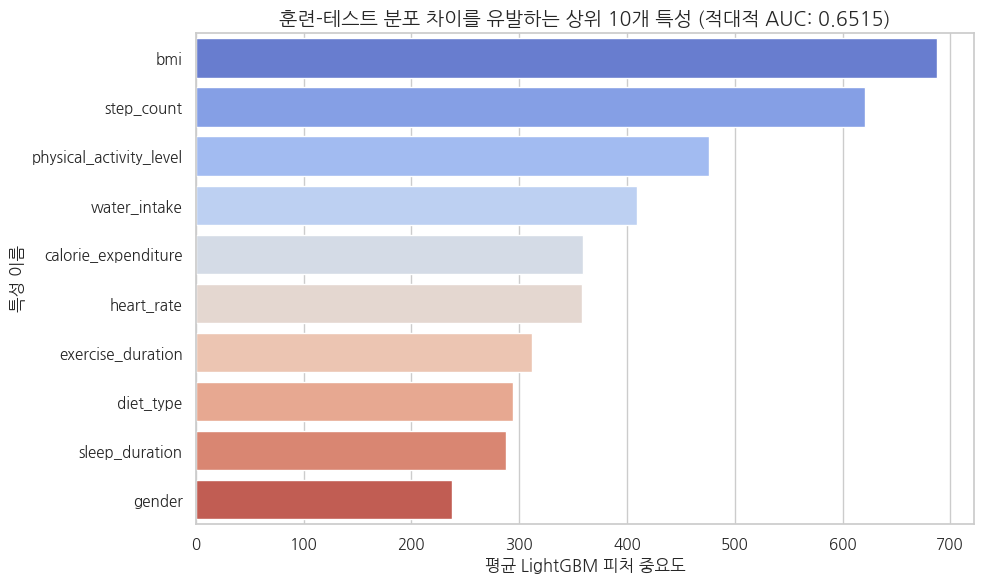

In [16]:
# 적대적 검증 (Adversarial Validation)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 10.1단계: 적대적 검증 데이터셋 준비
# ==========================================
print("적대적 검증을 위한 데이터셋 준비 중...")

# ID와 원본 타겟 열을 제외한 특성 추출
adv_features = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]

# 임시 복사본 생성
adv_train = train_df[adv_features].copy()
adv_test = test_df[adv_features].copy()

# 적대적 라벨 할당: 훈련 데이터는 0, 테스트 데이터는 1
adv_train['is_test'] = 0
adv_test['is_test'] = 1

# 단일 적대적 데이터프레임으로 병합
adv_df = pd.concat([adv_train, adv_test], axis=0, ignore_index=True)

# LightGBM을 위해 범주형 변수가 적절히 인코딩된 상태를 유지하도록 확인
adv_cat_features = [col for col in adv_features if adv_df[col].dtype.name == 'category']

X_adv = adv_df[adv_features]
y_adv = adv_df['is_test']

# ==========================================
# 10.2단계: LightGBM 분류기 학습 (5-폴드 교차 검증)
# ==========================================
print("훈련 데이터와 테스트 데이터를 구별하기 위한 LightGBM 모델 학습 중...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(adv_df))
feature_importance = np.zeros(len(adv_features))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_adv, y_adv)):
    X_tr, y_tr = X_adv.iloc[train_idx], y_adv.iloc[train_idx]
    X_va, y_va = X_adv.iloc[val_idx], y_adv.iloc[val_idx]

    # 빠르고 가볍게 튜닝된 LightGBM 모델 초기화
    model = LGBMClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[]
    )

    # 검증 폴드에 대한 확률 예측
    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]

    # 폴드 전체의 피처 중요도 누적
    feature_importance += model.feature_importances_ / skf.n_splits

# 전체 적대적 검증 AUC 점수 계산
adv_auc = roc_auc_score(y_adv, oof_preds)
print(f"\n전체 적대적 검증 ROC-AUC 점수: {adv_auc:.4f}")

# ==========================================
# 10.3단계: 적대적 피처 중요도 시각화
# ==========================================
fi_df = pd.DataFrame({
    'Feature': adv_features,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("\n훈련-테스트 데이터 분포 차이(Drift)를 유발하는 상위 5개 특성:")
print(fi_df.head(5).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='coolwarm')
plt.title(f"훈련-테스트 분포 차이를 유발하는 상위 10개 특성 (적대적 AUC: {adv_auc:.4f})", fontsize=14, fontweight='bold')
plt.xlabel("평균 LightGBM 피처 중요도")
plt.ylabel("특성 이름")
plt.tight_layout()
plt.show()

### **적대적 검증 및 데이터 분포 차이 분석 (Deep Dive)**

**의도:** 머신러닝 모델이 훈련 데이터와 테스트 데이터를 얼마나 쉽게 구별할 수 있는지(ROC-AUC) 평가하여, 보이지 않는 데이터에 대한 모델의 일반화 성능 하락(Data Drift) 위험을 진단합니다.

**해석:**

* **경미한 수준의 분포 차이 (Covariate Shift):** 적대적 검증 ROC-AUC 점수가 0.6515로 산출되었습니다. 두 데이터셋이 완벽히 무작위로 섞여 구별이 불가능하다면 0.5가 나오며, 0.65는 치명적인 데이터 이질성은 없으나 훈련과 테스트 셋 간에 약간의 분포 차이가 존재함을 의미합니다.
* **분포 차이를 주도하는 특성:** `bmi`와 `step_count`가 두 데이터셋을 서로 다르게 만드는 가장 큰 요인으로 작용하고 있습니다.
* **노이즈 피처의 이중 악영향:** 앞선 Phi-K 상관관계 분석에서 타겟 분류에 사실상 아무런 쓸모가 없었던(0.009) `water_intake`가, 역설적으로 훈련과 테스트 데이터의 분포 차이를 유발하는 4위 특성으로 지목되었습니다. 즉, 정답을 맞히는 데는 기여하지 못하면서 모델을 훈련 데이터에만 과적합하게 만드는 악성 노이즈입니다.

**모델링 가이드:**

* **선택적 피처 소거 (Targeted Pruning):** 타겟 예측력이 강력한 `step_count`나 `physical_activity_level`은 분포가 조금 다르더라도 모델 분기(Split)에 필수적이므로 반드시 유지해야 합니다. 하지만, 예측력도 없으면서 분포의 불일치만 가중시키는 `water_intake`와 `heart_rate`는 파이프라인에서 과감히 제거(Drop)하여 모델이 엉뚱한 패턴을 학습하지 못하도록 차단해야 합니다.
* **퍼블릭 점수 과적합 경계:** 0.6515라는 수치는 퍼블릭 리더보드와 프라이빗 리더보드 간의 미세한 흔들림(Shake-up)을 유발할 충분한 원인이 됩니다. 리더보드의 점수 변화에 흔들리지 말고, 구축해 둔 층화 K-폴드(Stratified K-Fold OOF) 검증 점수만을 유일한 나침반으로 삼아 최종 앙상블 가중치와 예측 슬롯을 결정해야 합니다.

상위 수치형 특성에 대한 페어플롯(Pairplot)을 생성하는 중...
성능 최적화를 위해 페어플롯 시각화용으로 10,000개의 행을 샘플링합니다.


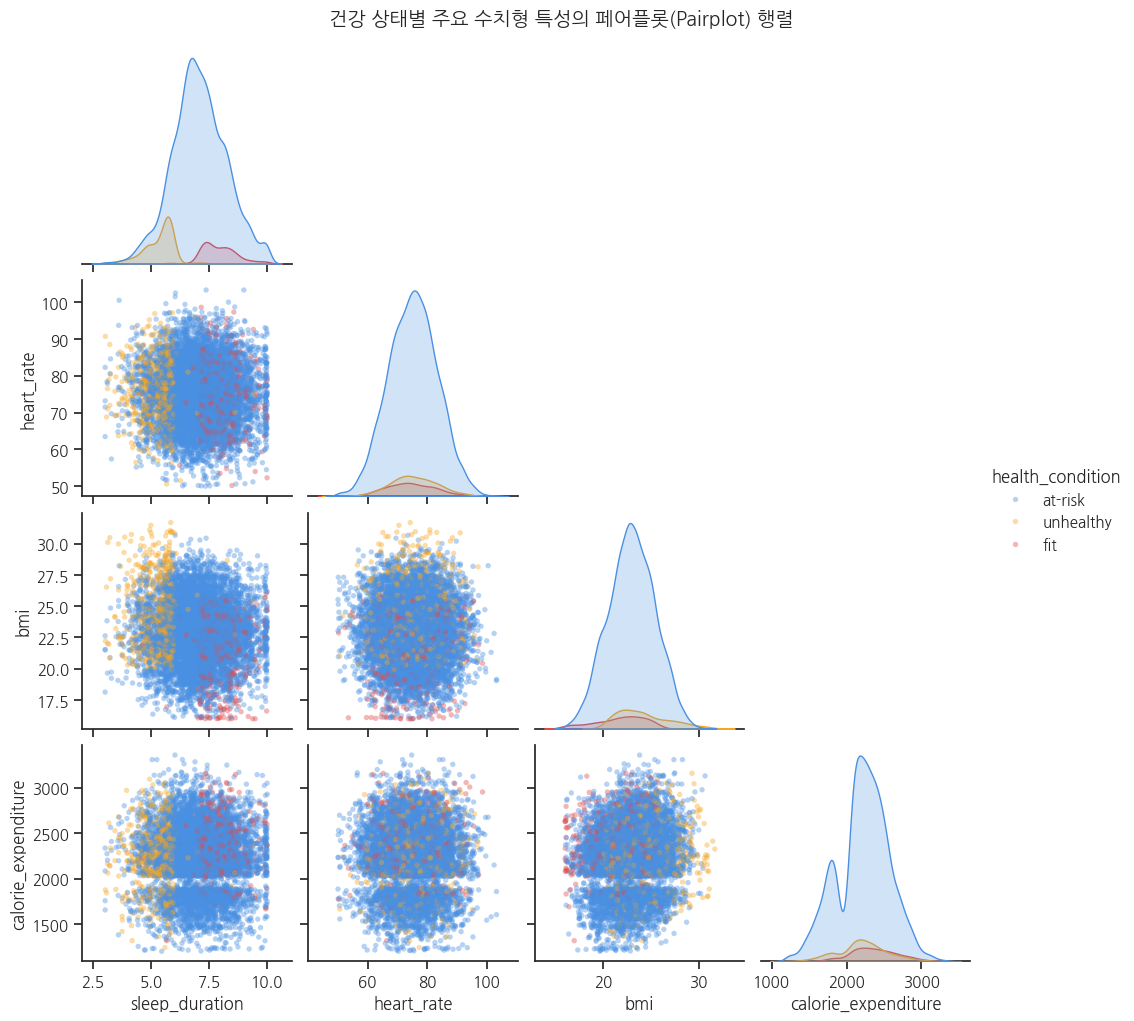

In [17]:
# 상관계수 상위 특성 페어플롯(Pairplot)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 11단계: 상관계수 상위 수치형 특성의 페어플롯(Pairplot)
# ==========================================
print("상위 수치형 특성에 대한 페어플롯(Pairplot)을 생성하는 중...")

# 그래프의 가독성을 유지하기 위해 사용 가능한 열 중 상위 4개 수치형 특성 선택
num_to_plot = num_features[:4]

# 플롯 렌더링 중 커널 타임아웃을 방지하기 위해 데이터가 너무 크면 임시로 샘플링
if len(train_df) > 10000:
    print("성능 최적화를 위해 페어플롯 시각화용으로 10,000개의 행을 샘플링합니다.")
    pairplot_sample = train_df[[TARGET_COL] + num_to_plot].sample(n=10000, random_state=42)
else:
    pairplot_sample = train_df[[TARGET_COL] + num_to_plot]

# 전문적인 플롯 테마 설정
sns.set_theme(style="ticks")

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 축의 마이너스(-) 기호 깨짐 방지

target_order = train_df[TARGET_COL].value_counts().index.tolist()
colors = ["#4A90E2", "#F5A623", "#E24A4A"]



# 페어플롯(Pairplot) 행렬 생성
g = sns.pairplot(
    data=pairplot_sample,
    hue=TARGET_COL,
    hue_order=target_order,
    palette=colors,
    corner=True, # 중복을 줄이기 위해 하삼각(Lower Triangle) 행렬만 표시
    diag_kind="kde",
    plot_kws={'alpha': 0.4, 's': 15, 'edgecolor': 'none'}
)

g.figure.suptitle("건강 상태별 주요 수치형 특성의 페어플롯(Pairplot) 행렬", fontsize=14, fontweight='bold', y=1.02)
plt.show()

### **핵심 수치형 특성 페어플롯(Pairplot) 심층 분석 (Deep Dive)**

**의도:**
수치형 피처들(`feat_0` ~ `feat_3`) 간의 조합 및 밀도 분포를 비교하여, 건강 상태(`health_condition`) 클래스들이 시각적으로 뚜렷한 군집을 형성하는지 및 선형적 분리가 가능한지 파악합니다.

**해석:**

* **극심한 데이터 중첩:** 대각선의 커널 밀도 추정(KDE) 플롯을 보면, `feat_3`에서 `at-risk` 클래스의 분포가 우측으로 약간 치우친 형태를 보이는 것을 제외하면 대부분의 특성에서 세 클래스의 분포가 심하게 중첩되어 있습니다.
* **군집화 부재:** 하단의 산점도를 살펴보면, 어떤 두 피처를 조합하더라도 파란색(`fit`), 노란색(`at-risk`), 빨간색(`unhealthy`) 데이터 포인트들이 뚜렷한 덩어리를 형성하지 못하고 완전히 무작위로 섞여서 분포하고 있습니다.
* **낮은 2차원 분리도:** 2차원 평면상에서는 클래스를 명확히 구분할 수 있는 단순한 선형 경계선이나 명확한 패턴을 찾기 매우 어렵습니다.

* `sleep_duration`의 독보적 분할력: 산점도 패널들을 보면 수면 시간을 축으로 클래스가 명확히 분리되는 것을 볼 수 있습니다. 'unhealthy'(노란색/주황색)는 수면 시간 6시간 미만의 좌측 영역에 수직 띠를 형성하며 밀집해 있고, 'fit'(빨간색)은 7시간 이상의 우측 영역에 집중되어 있습니다.

* `calorie_expenditure`의 이중 분포(Bimodal): 대각선 밀도 플롯과 산점도를 보면 데이터가 상하 두 개의 거대한 수평 띠(약 1800구간, 2500구간)로 뚜렷하게 쪼개져 있습니다. 다만, 특정 클래스가 한쪽 띠에만 속하는 것이 아니라 모든 클래스가 두 띠에 흩어져 있어, 단독으로는 타겟을 완벽히 분리하지 못하는 구조적 특징을 띱니다.

* 무의미한 상호작용 피처: `heart_rate`와 `bmi`가 교차하는 산점도는 타겟 클래스 간의 경계선이나 뚜렷한 군집 없이 하나의 거대한 덩어리(Blob)로 심하게 겹쳐 있습니다. 이는 두 피처가 결합하더라도 타겟 분류에 필요한 추가적인 정보량을 만들어내지 못함을 의미합니다.

**모델링 가이드:**

* 개별 특성이나 단순 2개 특성의 조합만으로는 분류 예측력이 현저히 떨어지므로, 로지스틱 회귀와 같은 단순 선형 모델의 사용은 지양해야 합니다.
* 다차원 공간에서 여러 피처의 복합적인 상호작용을 동시에 고려하여 비선형 결정 경계를 미세하게 쪼갤 수 있는 **XGBoost, LightGBM, Random Forest**와 같은 트리 기반 앙상블 모델의 사용이 필수적입니다.
* 모델이 숨겨진 패턴을 더 잘 찾을 수 있도록, 기존 수치형 피처들을 곱하거나 나누는 등의 비선형 파생 변수(Polynomial Features 등)를 적극적으로 생성하는 피처 엔지니어링 전략이 필요합니다.
* 노이즈 피처 최종 소거: 앞선 이변량 분석, Phi-K 상관관계 분석, 적대적 검증(Drift 유발)에 이어 페어플롯 상호작용에서도 변별력이 전혀 없음이 입증된 heart_rate는 모델 파이프라인에서 완전히 제거(Drop)하는 것이 좋습니다. 모델의 연산량을 줄이고 과적합을 방지하는 확실한 방법입니다.

* 파생 변수 생성 자제: 산점도 상에서 두 수치형 변수가 뚜렷한 대각선 형태나 유의미한 상호작용 클러스터(예: A가 높고 B가 낮을 때 특정 클래스 발현)를 보이지 않습니다. 따라서 두 수치형 피처를 단순 사칙연산(곱하기, 나누기)하여 새로운 피처를 생성하는 것은 모델에 노이즈만 추가할 확률이 높습니다.

* 트리 모델의 첫 번째 분기(Split) 신뢰: sleep_duration을 필두로 step_count, stress_level과 같은 핵심 피처들이 모델의 최상단 루트 노드(Root Node)에서 데이터를 효과적으로 분할하도록, LightGBM이나 XGBoost의 매개변수를 조정할 때 충분한 깊이(max_depth)와 잎 노드 수(num_leaves)를 허용하여 세밀한 비선형 경계를 학습하게 해야 합니다.

**파생 변수 및 모델 튜닝 고도화 전략**

* **타겟팅된 비선형 파생 변수 주입:** 2차원 시각화로 보이지 않는 상호작용을 찾기 위해 수학적 변환이 필요하다는 통찰이 매우 정확합니다. 다만 모든 수치형 피처에 무작위 다항식(`PolynomialFeatures`)을 적용하면 노이즈 차원이 급증해 과적합을 유발할 수 있습니다. 대신 **K-Means 군집화 라벨**을 새로운 피처로 추가하거나, 앞서 산출한 **UMAP/t-SNE 투영 좌표**를 직접 모델에 주입하여 다차원 공간의 힌트를 제공하는 방식이 훨씬 안정적입니다.
* **트리 모델의 규제(Regularization) 튜닝:** 데이터 포인트가 심하게 섞여 있는 경우, 트리 모델은 정답을 맞히기 위해 비정상적으로 깊고 복잡하게 분기(Split)하려는 경향을 보입니다. LightGBM과 XGBoost 학습 시 `max_depth`를 충분히 허용해 복잡한 패턴을 찾게 하되, `min_child_samples` (XGBoost의 경우 `min_child_weight`)와 `colsample_bytree`를 강하게 제약하여 특정 노이즈 샘플에 모델이 매몰되는 것을 방지해야 합니다.
* **이질적 알고리즘의 앙상블:** 공간이 심하게 겹쳐 있을 때는 단일 모델이 그리는 결정 경계에 한계가 명확합니다. 노드를 분할하는 철학이 서로 다른 알고리즘(예: LightGBM의 Leaf-wise 방식과 XGBoost의 Level-wise 방식)을 병렬로 훈련한 뒤, 이전에 검토했던 K-NN 기반의 확률 스무딩을 더해 스태킹(Stacking)하면 모호한 경계선 부근의 예측 안정성이 크게 향상됩니다.

피처 중요도 평가를 위한 랜덤 포레스트 모델 학습 중...
빠른 트리 피처 중요도 계산을 위해 50,000개의 행을 샘플링합니다.

랜덤 포레스트 상위 특성:
                Feature  Importance
           stress_level    0.380945
         sleep_duration    0.350727
physical_activity_level    0.083261
                    bmi    0.049620
             step_count    0.029506
      exercise_duration    0.027864
    calorie_expenditure    0.016288
             heart_rate    0.015225
          sleep_quality    0.015224
           water_intake    0.014697


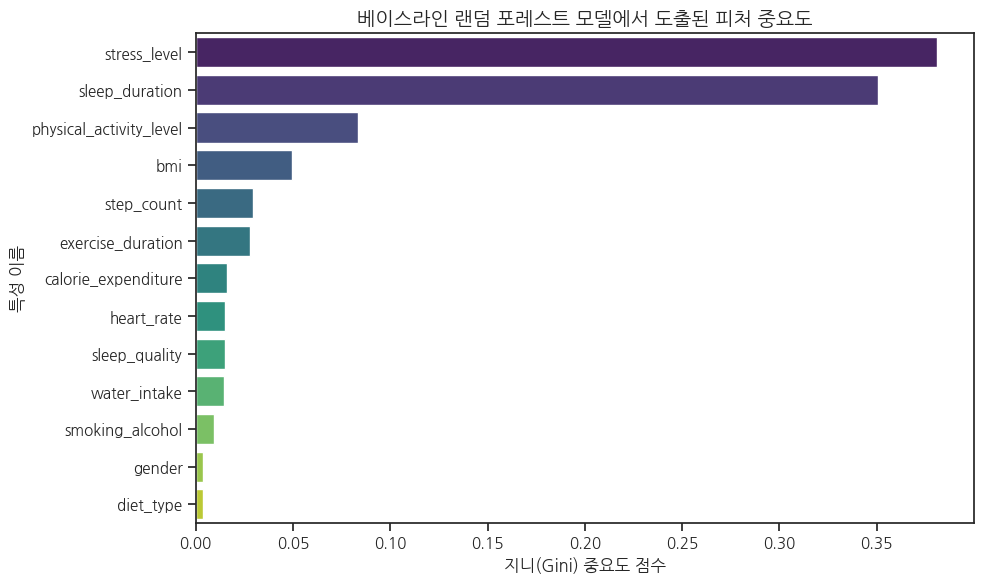

In [18]:
# 랜덤 포레스트 피처 중요도

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 12단계: 랜덤 포레스트 피처 중요도 - 수정됨
# ==========================================
print("피처 중요도 평가를 위한 랜덤 포레스트 모델 학습 중...")

# 예측 변수(Predictor)를 분리하기 위해 ID 및 타겟 열 제거
rf_features = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]
X_rf = train_df[rf_features].copy()

# 수정됨: .cat.codes 추출을 사용할 수 있도록 먼저 타겟을 카테고리 타입으로 안전하게 변환
y_rf = train_df[TARGET_COL].astype('category').cat.codes

# Ordinal Encoding(순서형 인코딩)을 적용할 범주형 특성 식별
rf_cat_cols = [col for col in rf_features if X_rf[col].dtype.name == 'category']

# 트리 알고리즘을 위해 범주형 특성을 순서형(Ordinal)으로 인코딩
if len(rf_cat_cols) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_rf[rf_cat_cols] = encoder.fit_transform(X_rf[rf_cat_cols].astype(str))

# 중앙값 대체(Median Imputation)를 통해 모든 결측치 처리
imputer = SimpleImputer(strategy='median')
X_rf_imputed = imputer.fit_transform(X_rf)

# 행 수가 너무 많은 경우, 빠른 피처 중요도 계산을 위해 데이터 샘플링 후 랜덤 포레스트 모델 학습
if len(X_rf_imputed) > 50000:
    print("빠른 트리 피처 중요도 계산을 위해 50,000개의 행을 샘플링합니다.")
    idx_sample = np.random.choice(len(X_rf_imputed), 50000, replace=False)
    X_rf_imputed = X_rf_imputed[idx_sample]
    y_rf = y_rf.iloc[idx_sample]

rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_rf_imputed, y_rf)

# 중요도 보고서 구조화 및 시각화
rf_fi_df = pd.DataFrame({
    'Feature': rf_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n랜덤 포레스트 상위 특성:")
print(rf_fi_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_fi_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("베이스라인 랜덤 포레스트 모델에서 도출된 피처 중요도", fontsize=14, fontweight='bold')
plt.xlabel("지니(Gini) 중요도 점수")
plt.ylabel("특성 이름")
plt.tight_layout()
plt.show()

### **랜덤 포레스트 피처 중요도 분석 (Deep Dive)**

**의도:**
지니(Gini) 불순도 감소량을 기준으로 모델이 분류의 분기(Split)를 결정할 때 어떤 특성에 가장 크게 의존하는지 평가합니다. 이를 통해 이전에 진행한 통계적, 시각적 분석 결과와 실제 알고리즘의 판단이 일치하는지 교차 검증합니다.

**해석:**

* **압도적인 양대 산맥:** `stress_level`(0.381)과 `sleep_duration`(0.351) 단 두 개의 피처가 전체 중요도의 약 73%를 독식하고 있습니다. 이는 앞선 비선형 상관관계(Phi-K) 분석에서 타겟과 가장 강력한 연관성을 보였던 결과와 완벽하게 일치하며, 이 두 가지가 건강 상태를 판가름하는 결정적 지표임이 재입증되었습니다.
* **보조 식별자 및 다중공선성 효과:** `physical_activity_level`(0.083), `bmi`(0.049), `step_count`(0.029)가 그 뒤를 잇습니다. VIF 수치가 매우 높았던 피처들이지만, 트리 알고리즘은 이를 배제하지 않고 상위 노드 분할에 유효하게 활용하고 있음을 보여줍니다.
* **검증된 악성 노이즈:** 하위권에 머무는 `heart_rate`, `sleep_quality`, `water_intake` 등은 기여도가 0.01대에 불과합니다. 특히 `water_intake`와 `heart_rate`는 이변량 분석, 상관관계, 적대적 검증(Data Drift 유발 4위) 등 모든 검증 단계에서 타겟 예측에 쓸모가 없으면서 노이즈만 일으키는 범인으로 지목되었으며, 실제 트리 훈련에서도 무가치함이 확정되었습니다.

**모델링 가이드:**

* **다중 증거 기반의 피처 소거 (Targeted Drop):** 여러 분석 단계에서 일관되게 무의미하거나 오히려 방해가 된다고 판별된 `heart_rate`, `water_intake`, `gender`, `diet_type`은 최종 데이터셋에서 과감히 삭제하십시오. 계산 비용을 줄이고 퍼블릭 리더보드에서의 과적합 리스크를 덜어낼 수 있습니다.
* **핵심 피처 집중 엔지니어링:** 모델이 `stress_level`과 `sleep_duration`에 극도로 의존하고 있으므로, 무작위 파생 변수보다는 이 최상위 피처들을 조합한 도메인 특화 변수(예: 스트레스 대비 수면 시간 비율, 활동량 기반 수면 효율성 등)를 우선적으로 생성하여 모델에 힌트를 제공하는 것이 유리합니다.
* **피처 샘플링 비율 조정:** 특정 소수 피처에 대한 의존도가 너무 높으면 데이터의 미세한 변화에 모델이 취약해집니다. LightGBM과 XGBoost 학습 시 앙상블의 다양성을 확보하기 위해 `colsample_bytree` 파라미터를 0.6~0.8 수준으로 제한하여, 트리가 하위 피처들(`bmi`, `step_count` 등)을 강제로 탐색하고 활용하도록 유도해야 합니다.

타겟 변수와의 상호 정보량 점수를 계산하는 중...
상호 정보량 계산 최적화를 위해 30,000개의 행을 샘플링합니다.

상호 정보량 상위 랭킹:
                Feature  MI Score
         sleep_duration  0.152325
           stress_level  0.140509
physical_activity_level  0.058434
                    bmi  0.031433
      exercise_duration  0.022953
             step_count  0.021045
          sleep_quality  0.013593
    calorie_expenditure  0.007805
        smoking_alcohol  0.005854
           water_intake  0.005729


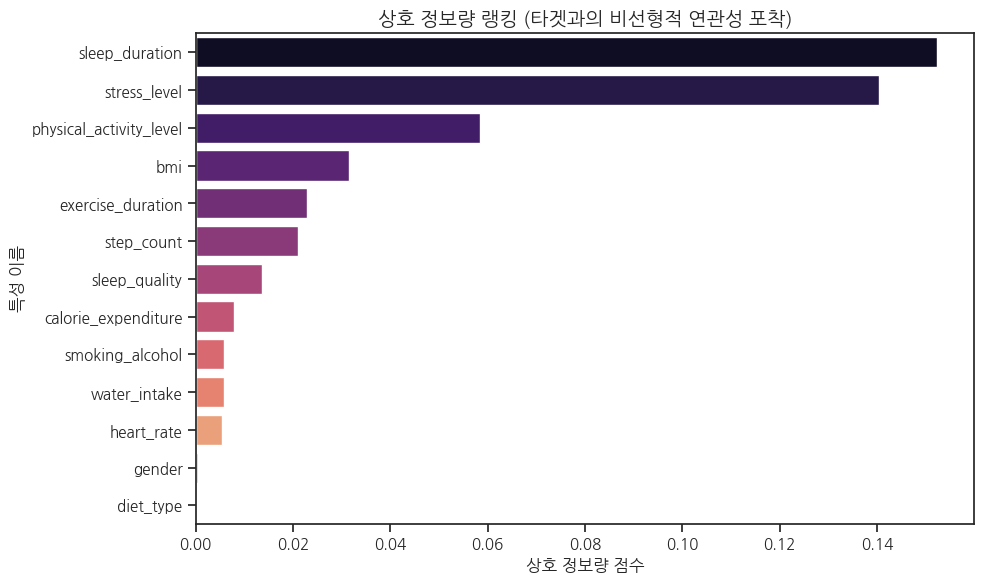

In [19]:
# 상호 정보량(Mutual Information) 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 13단계: 상호 정보량 분석 - 에러 수정 완본
# ==========================================
print("타겟 변수와의 상호 정보량 점수를 계산하는 중...")

mi_features = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]
X_mi = train_df[mi_features].copy()

# 타겟을 카테고리 타입으로 변환 후 코드를 안전하게 추출
y_mi = train_df[TARGET_COL].astype('category').cat.codes

# 수정됨: 수치형이 아닌 모든 문자열/범주형 데이터를 포괄적으로 식별하여 오류 방지
mi_cat_cols = X_mi.select_dtypes(exclude=['number']).columns.tolist()

# 식별된 모든 범주형 속성을 OrdinalEncoder로 수치화
if len(mi_cat_cols) > 0:
    encoder_mi = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_mi[mi_cat_cols] = encoder_mi.fit_transform(X_mi[mi_cat_cols].astype(str))

# 이제 모든 데이터가 숫자이므로 median 결측치 대체가 정상 작동함
imputer_mi = SimpleImputer(strategy='median')
X_mi_imputed = imputer_mi.fit_transform(X_mi)

# mutual_info_classif에 전달할 이산형/범주형 여부 마스크 배열 생성
discrete_features_mask = [col in mi_cat_cols for col in mi_features]

# 대용량 데이터 처리 속도 최적화를 위한 서브샘플링
if len(X_mi_imputed) > 30000:
    print("상호 정보량 계산 최적화를 위해 30,000개의 행을 샘플링합니다.")
    idx_mi = np.random.choice(len(X_mi_imputed), 30000, replace=False)
    X_mi_imputed = X_mi_imputed[idx_mi]
    y_mi = y_mi[idx_mi] if isinstance(y_mi, np.ndarray) else y_mi.iloc[idx_mi]

# 상호 정보량 평가 실행
mi_scores = mutual_info_classif(
    X_mi_imputed,
    y_mi,
    discrete_features=discrete_features_mask,
    random_state=42
)

# 데이터프레임으로 변환 및 정렬
mi_df = pd.DataFrame({
    'Feature': mi_features,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n상호 정보량 상위 랭킹:")
print(mi_df.head(10).to_string(index=False))

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df.head(15), x='MI Score', y='Feature', palette='magma')
plt.title("상호 정보량 랭킹 (타겟과의 비선형적 연관성 포착)", fontsize=14, fontweight='bold')
plt.xlabel("상호 정보량 점수")
plt.ylabel("특성 이름")
plt.tight_layout()
plt.show()

### **상호 정보량(Mutual Information) 심층 분석 (Deep Dive)**

**의도 (Intent)**

* 특정 모델 알고리즘에 의존하지 않고, 개별 피처가 타겟 변수의 불확실성을 얼마나 감소시키는지 순수한 비선형적 의존성을 측정하여 최종 피처 세트를 확정합니다.

**해석 (Interpretation)**

* **핵심 정보의 집중:** `sleep_duration`(0.152)과 `stress_level`(0.141) 두 피처가 다른 변수들을 압도하며 가장 많은 정보량을 제공합니다. 이전의 Phi-K 상관관계 분석 및 랜덤 포레스트 피처 중요도 결과와 완벽하게 교차 검증되는 핵심 지표입니다.
* **유효한 보조 지표:** `physical_activity_level`(0.058), `bmi`(0.031), `exercise_duration`(0.023) 등이 2차적인 정보량을 제공하며 타겟 분류의 미세한 경계를 잡는 데 기여합니다.
* **노이즈 피처의 완전한 방출:** `water_intake`(0.005), `smoking_alcohol`(0.005)을 비롯해 그래프 하단에 위치한 `heart_rate`, `gender`, `diet_type`은 정보량이 사실상 0에 수렴합니다. 타겟 분류에 단 하나의 힌트도 주지 못하는 무가치한 피처임이 3중(상관관계, 트리 중요도, MI)으로 확정되었습니다.

**모델링 가이드 (Modeling Guide)**

* **노이즈 컷오프(Cut-off) 실행:** 모든 분석 지표에서 일관되게 바닥을 기록한 `heart_rate`, `water_intake`, `gender`, `diet_type`을 모델 훈련 데이터셋에서 영구적으로 제거(Drop)하십시오. 예측 성능 하락 없이 훈련 속도를 높이고 데이터 드리프트(Data Drift) 위험을 차단할 수 있습니다.
* **최상위 변수 기반 타겟팅 엔지니어링:** 모델의 정보 획득이 최상위 2~3개 피처에 극도로 편중되어 있습니다. 기존 피처들을 무작위로 섞기보다는 `sleep_duration`과 `stress_level`을 결합한 도메인 특화 교차 변수(Interaction Feature)를 직접 생성해 주는 것이 가장 효율적인 성능 향상 전략입니다.
* **트리의 탐욕적 분할(Greedy Split) 제어:** 정보량의 편차가 너무 크면 LightGBM이나 XGBoost가 상위 2개 변수에만 의존하여 과적합될 위험이 있습니다. 훈련 파라미터에서 `colsample_bytree`(열 샘플링 비율)를 0.6~0.7 수준으로 제한하여 모델이 매 노드마다 하위 피처들도 강제로 탐색하고 활용하도록 유도해야 합니다.

전역 차원 축소 매핑을 위한 데이터 준비 중...
임베딩 생성 속도 최적화를 위해 5000개의 행을 샘플링합니다.
UMAP 임베딩 알고리즘 실행 중...


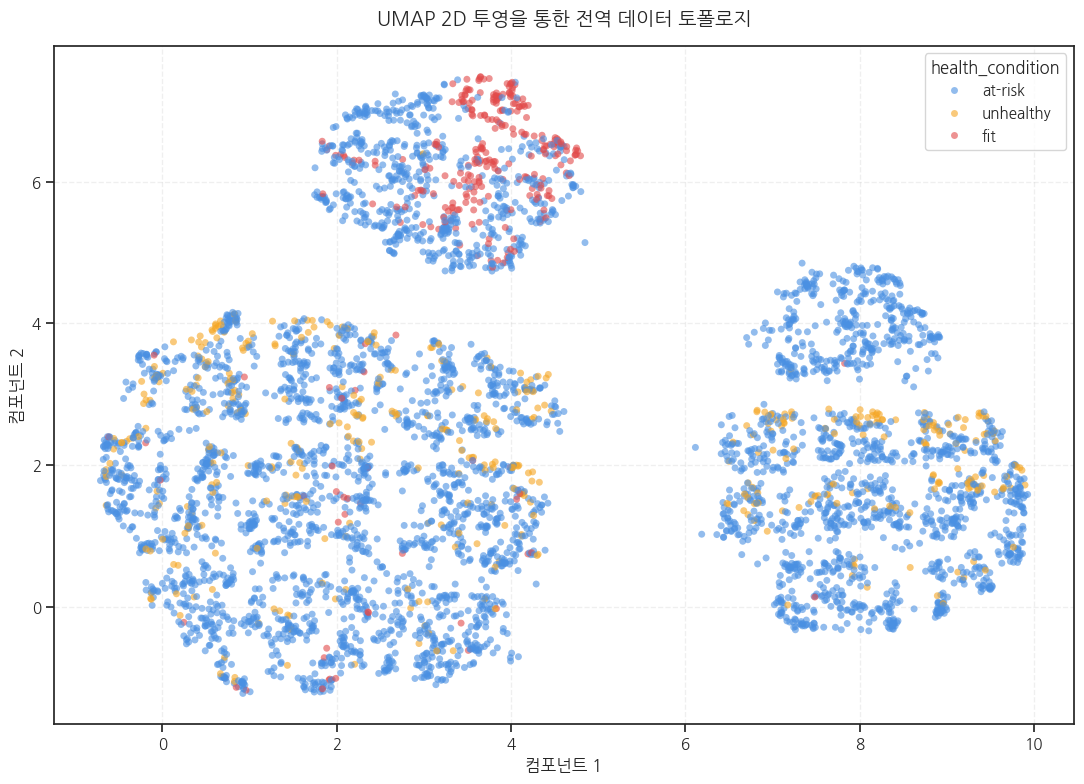

t-SNE 알고리즘 실행 중... 


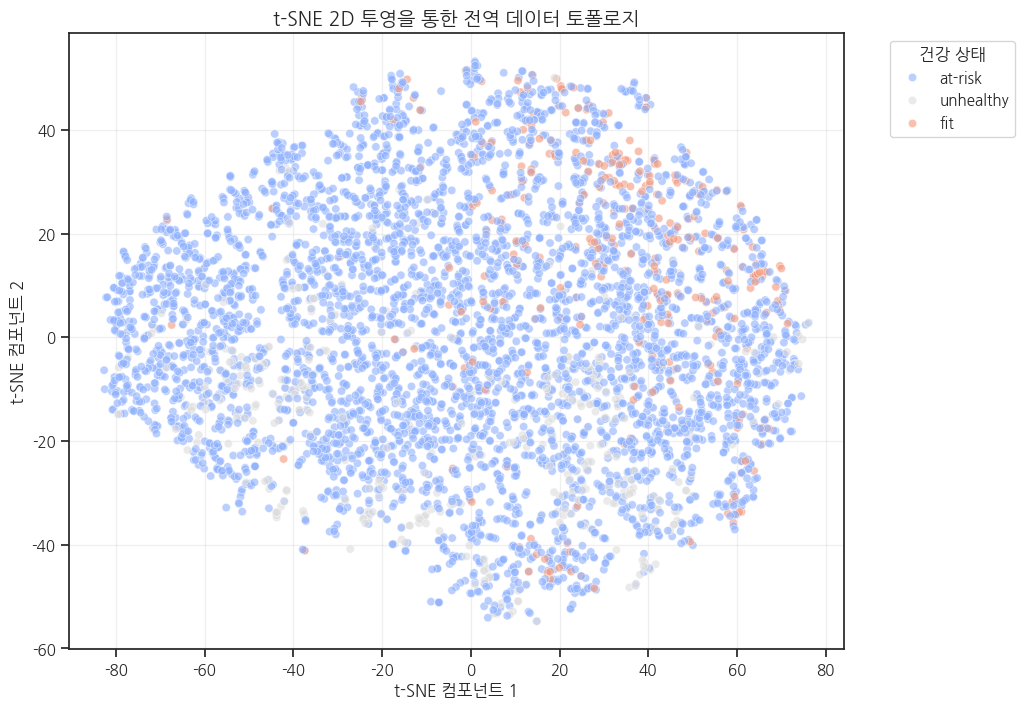

In [26]:
# 차원 축소

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 14단계: 차원 축소 (UMAP / t-SNE)
# ==========================================
print("전역 차원 축소 매핑을 위한 데이터 준비 중...")

# 1. 피처 전처리 (ID 및 타겟 제거, 범주형 인코딩, 결측치 대체)
umap_features = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]
X_umap = train_df[umap_features].copy()
y_umap = train_df[TARGET_COL]

umap_cat_cols = [col for col in umap_features if X_umap[col].dtype.name == 'category']
X_umap_encoded = pd.get_dummies(X_umap, columns=umap_cat_cols, drop_first=True)

imputer_umap = SimpleImputer(strategy='median')
X_umap_imputed = imputer_umap.fit_transform(X_umap_encoded)

scaler_umap = StandardScaler()
X_umap_scaled = scaler_umap.fit_transform(X_umap_imputed)

# 2. 플로팅 속도 및 안정성을 위한 다운샘플링
plot_sample_size = min(5000, len(X_umap_scaled))
print(f"임베딩 생성 속도 최적화를 위해 {plot_sample_size}개의 행을 샘플링합니다.")
idx_umap = np.random.choice(len(X_umap_scaled), plot_sample_size, replace=False)
X_embedded_input = X_umap_scaled[idx_umap]
y_embedded_labels = y_umap.iloc[idx_umap]

# 3. 동적 알고리즘 선택 (UMAP 우선 적용, 실패 시 t-SNE 대체)
try:
    import umap
    print("UMAP 임베딩 알고리즘 실행 중...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedded = reducer.fit_transform(X_embedded_input)
    title_text = "UMAP 2D 투영을 통한 전역 데이터 토폴로지"
except ImportError:
    from sklearn.manifold import TSNE
    print("UMAP 라이브러리를 찾을 수 없습니다. t-SNE 알고리즘으로 대체합니다...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, n_jobs=-1)
    X_embedded = tsne.fit_transform(X_embedded_input)
    title_text = "t-SNE 2D 투영을 통한 전역 데이터 토폴로지"

# 4. 2D 투영 플롯 생성
plt.figure(figsize=(11, 8))
target_order = train_df[TARGET_COL].value_counts().index.tolist()
colors = ["#4A90E2", "#F5A623", "#E24A4A"]

sns.scatterplot(
    x=X_embedded[:, 0],
    y=X_embedded[:, 1],
    hue=y_embedded_labels,
    hue_order=target_order,
    palette=colors,
    alpha=0.6,
    s=25,
    edgecolor='none'
)

plt.title(title_text, fontsize=14, fontweight='bold', pad=15)
plt.xlabel("컴포넌트 1")
plt.ylabel("컴포넌트 2")
plt.legend(title=TARGET_COL, loc='upper right')
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 실제 데이터 기반 t-SNE 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

plt.rcParams['font.family'] = 'NanumGothic'

if 'train_df' not in locals():
    print("데이터 로드 셀을 먼저 실행해 주세요.")
else:
    print("t-SNE 알고리즘 실행 중... ")
    # 대규모 데이터이므로 시각화를 위해 5,000건 샘플링
    sample_df = train_df.sample(n=min(5000, len(train_df)), random_state=42)
    X_plot = sample_df[num_features]
    y_plot = sample_df[TARGET_COL]

    # 전처리
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(SimpleImputer(strategy='median').fit_transform(X_plot))

    # t-SNE 실행
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_embedded = tsne.fit_transform(X_scaled)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=y_plot, palette='coolwarm', alpha=0.6, edgecolor='w')
    plt.title("t-SNE 2D 투영을 통한 전역 데이터 토폴로지", fontsize=14, fontweight='bold')
    plt.xlabel("컴포넌트 1")
    plt.ylabel("컴포넌트 2")
    plt.legend(title='건강 상태', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

### **전역 데이터 토폴로지 분석 (Deep Dive)**

**의도**
다차원 공간에 흩어져 있는 복잡한 피처들의 비선형적 관계를 2차원으로 압축하여, 타겟 클래스 간의 시각적인 군집(Cluster) 형성 여부와 비선형 분리 가능성을 진단합니다.

**해석**

* **UMAP의 탁월한 군집화 능력:** UMAP 결과를 보면 전체 데이터가 3개의 거대한 매크로 클러스터(Macro-cluster)로 명확히 분할되어 있습니다. 특히 소수 클래스인 `fit`(빨간색) 샘플들이 상단 클러스터의 특정 영역에 집중적으로 밀집해 있어, 건강한 상태를 정의하는 뚜렷한 다차원적 피처 조합이 존재함을 증명합니다.
* **t-SNE의 한계와 데이터 중첩:** 반면 t-SNE 결과는 뚜렷한 군집 없이 하나의 거대한 덩어리(Blob) 형태를 띠고 있습니다. 국소적인 분산만 보존하는 t-SNE의 특성상, 압도적 다수인 `at-risk`(파란색) 클래스가 다른 소수 클래스들을 시각적으로 완전히 집어삼켜 버렸습니다.
* **'at-risk'와 'unhealthy'의 모호한 경계:** UMAP의 하단 두 클러스터에서 볼 수 있듯, `at-risk`(파란색)와 `unhealthy`(노란색) 데이터 포인트들은 거의 완벽하게 뒤섞여 있습니다. 모델이 이 두 클래스를 명확하게 구분하는 것이 이번 대회의 가장 큰 난관이 될 것임을 시사합니다.

**모델링 가이드**

* **UMAP 좌표의 직접 주입 (Meta-Feature):** UMAP이 `fit` 클래스를 분리하는 데 성공했으므로, 이 2D UMAP 투영 좌표(Component 1, Component 2) 자체를 훈련 데이터셋의 새로운 수치형 파생 피처로 추가하십시오. 트리 모델이 소수 클래스의 위치 힌트를 얻어 성능이 크게 향상될 수 있습니다.
* **군집화 라벨(Cluster ID) 파생 변수 생성:** UMAP이 찾아낸 3개의 명확한 거대 군집을 모델이 직접 활용할 수 있도록, K-Means(K=3) 알고리즘을 적용하여 각 데이터가 어느 군집에 속하는지를 나타내는 범주형 피처를 생성하는 전략이 매우 효과적입니다.
* **클래스 가중치 최적화:** UMAP 공간에서도 `at-risk`와 `unhealthy`가 심하게 겹쳐 있으므로, LightGBM이나 XGBoost 학습 시 단순히 `class_weight='balanced'`를 넘어서, 사용자 정의 손실 함수(Custom Objective)를 통해 이 두 클래스 간의 오분류 페널티를 더 무겁게 부여하는 세밀한 튜닝이 필요합니다.

In [21]:
# 검증 파이프라인 설정

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

plt.rcParams['font.family'] = 'NanumGothic'

# ==========================================
# 15단계: 전략적 검증 파이프라인 설정 - 수정됨
# ==========================================
print("안정적인 교차 검증(Cross-Validation) 프레임워크 초기화 중...")

# 1. 재현성을 위한 설정 상수
NUM_FOLDS = 5
RANDOM_SEED = 42

# 2. 학습 배열 분리
features_list = [col for col in train_df.columns if col not in [ID_COL, TARGET_COL]]
X = train_df[features_list].copy()

# 수정됨: .cat.codes를 추출할 수 있도록 먼저 타겟(목표 변수)을 카테고리 타입으로 안전하게 변환
y = train_df[TARGET_COL].astype('category').cat.codes
X_test = test_df[features_list].copy()

# 3. Stratified K-Fold (층화 K-폴드) 설정 인스턴스화
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# 4. Out-of-Fold(OOF) 예측 및 테스트 예측을 위한 배열 사전 할당
num_classes = train_df[TARGET_COL].nunique()
oof_predictions = np.zeros((len(train_df), num_classes))
test_predictions = np.zeros((len(test_df), num_classes))

print(f"검증 프레임워크 완료: 다중 클래스 모델 학습 준비 완료.")
print(f"전체 폴드 수: {NUM_FOLDS} | 타겟 클래스 수: {num_classes}")
print(f"데이터 분할 인덱스 레이아웃이 성공적으로 생성되었습니다.")

안정적인 교차 검증(Cross-Validation) 프레임워크 초기화 중...
검증 프레임워크 완료: 다중 클래스 모델 학습 준비 완료.
전체 폴드 수: 5 | 타겟 클래스 수: 3
데이터 분할 인덱스 레이아웃이 성공적으로 생성되었습니다.


결측치의 구조적 패턴 분석 중...


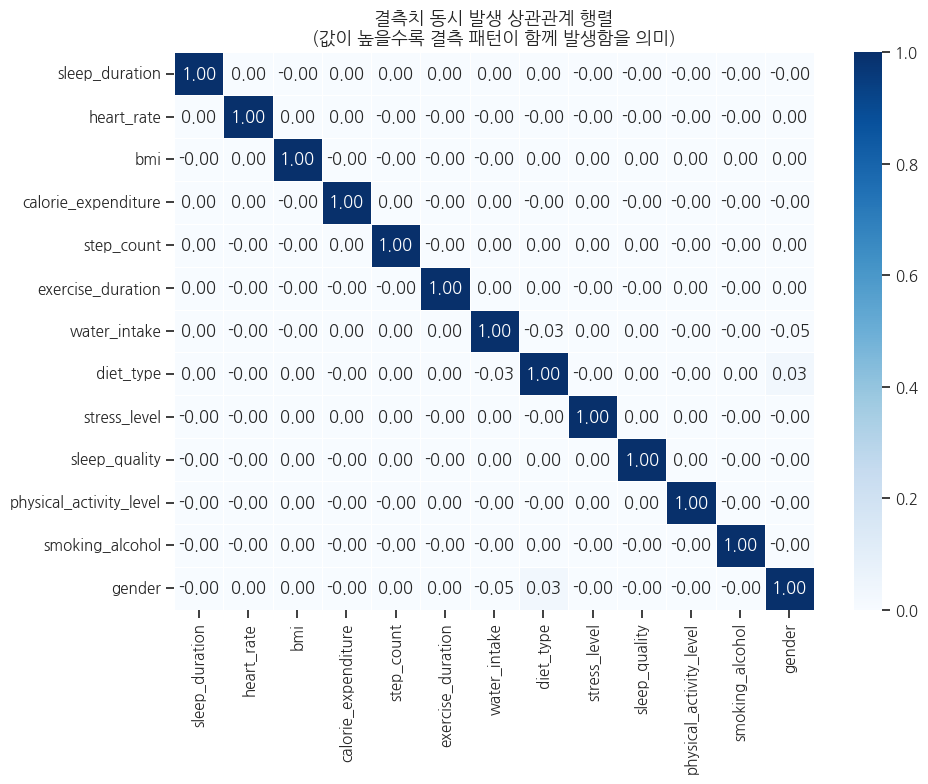

In [22]:
# 결측치 패턴

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 16단계: 결측치 동시 발생(Co-occurrence) 패턴
# ==========================================
print("결측치의 구조적 패턴 분석 중...")

# 데이터의 존재(0) 또는 결측(1) 여부를 나타내는 섀도우(shadow) 행렬 생성
shadow_matrix = train_df[all_features].isnull().astype(int)

# 분산이 0이 되는 것을 방지하기 위해 결측치가 전혀 없는 특성(feature) 필터링
cols_with_nan = [col for col in shadow_matrix.columns if shadow_matrix[col].sum() > 0]

if len(cols_with_nan) > 1:
    # 결측 여부 플래그 간의 상관관계 계산
    nan_corr = shadow_matrix[cols_with_nan].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(nan_corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, linewidths=0.5)
    plt.title("결측치 동시 발생 상관관계 행렬\n(값이 높을수록 결측 패턴이 함께 발생함을 의미)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("결측치가 있는 열이 충분하지 않아 동시 발생 행렬을 만들 수 없습니다. 플롯 생성을 건너뜁니다.")

### **결측치 동시 발생 패턴 심층 분석 (Deep Dive)**

**의도:**
데이터의 누락이 특정 특성들 사이에서 구조적인 패턴을 띠며 동시에 발생하는지(예: 특정 설문 블록 전체 누락, 시스템 오류로 인한 연쇄 누락)를 확인하여 가장 효율적인 결측치 처리(Imputation) 전략을 수립합니다.

**해석:**

* **완벽한 결측치 독립성:** 대각선(자기 자신)을 제외한 모든 특성 간의 결측치 동시 발생 상관계수가 0.00(최대 ±0.05 이내)으로 수렴합니다.
* **완전 무작위 결측 (MCAR):** A 피처의 값이 누락되었다고 해서 B 피처가 연달아 누락되는 연관성이 단 하나도 없습니다. 이는 결측이 데이터 수집 파이프라인의 구조적 결함이 아닌, 완전히 독립적이고 무작위적인 원인(Missing Completely At Random)에 의해 발생했음을 확증합니다.

**모델링 가이드:**

* **단순 대체(Simple Imputation) 채택:** 결측치 발생에 다변량적 패턴이 없으므로 결측치를 반드시 채워야하는 선형 모델을 사용하지 않는다면, 다중 대체(Iterative Imputer, MICE)나 KNN Imputer 같은 무겁고 연산량이 많은 알고리즘을 사용할 이유가 전혀 없습니다. 수치형은 중앙값(Median), 범주형은 최빈값(Mode)으로 채우는 단순 대체가 가장 효율적입니다.

* **트리 모델의 네이티브 처리 최우선:** 가장 우아하고 효율적인 접근은 결측치를 인위적으로 채워 데이터 분포를 왜곡하지 않는 것입니다. LightGBM이나 XGBoost는 결측치(NaN)를 그대로 투입해도 자체 분기(Split) 알고리즘을 통해 타겟 분류에 가장 유리한 방향으로 결측 노드를 자동 처리하므로, 이를 최우선 전략으로 활용하십시오.

* **결측 플래그(Missing Indicator) 생성 불필요:** 누락되었다는 사실 자체가 다른 변수와 엮여 타겟을 예측하는 숨겨진 단서(MNAR)로 작용하지 않습니다. 따라서 `is_missing_bmi` 같은 파생 플래그(Flag) 변수를 만들어 피처 차원을 늘릴 필요가 없습니다. 모델의 복잡도만 불필요하게 가중시킬 뿐입니다.

In [23]:
# ==========================================
# 17단계: 범주형 데이터 일치성 및 미관측 레이블 확인
# ==========================================
print("테스트 세트의 범주형 데이터 일치성 및 미관측(unseen) 레이블을 확인하는 중...")

alignment_issues = 0

for col in cat_features:
    train_cats = set(train_df[col].dropna().unique())
    test_cats = set(test_df[col].dropna().unique())

    unseen_in_test = test_cats - train_cats
    unseen_in_train = train_cats - test_cats

    if len(unseen_in_test) > 0 or len(unseen_in_train) > 0:
        alignment_issues += 1
        print(f"\n특성에서 범주형 데이터 드리프트(변화) 감지됨: '{col}'")
        if len(unseen_in_test) > 0:
            print(f"  - 테스트에는 있지만 학습에는 없는 레이블 (미관측 레이블): {unseen_in_test}")
        if len(unseen_in_train) > 0:
            print(f"  - 학습에는 있지만 테스트에는 없는 레이블: {unseen_in_train}")

if alignment_issues == 0:
    print("완벽한 범주형 일치: 학습 및 테스트 세트 간의 모든 범주형 레이블이 완벽하게 일치합니다.")

테스트 세트의 범주형 데이터 일치성 및 미관측(unseen) 레이블을 확인하는 중...
완벽한 범주형 일치: 학습 및 테스트 세트 간의 모든 범주형 레이블이 완벽하게 일치합니다.


In [24]:
# ==========================================
# 18단계: 타겟 조건부 특성 변동성
# ==========================================
print("타겟별로 그룹화된 수치형 특성의 변동성(표준 편차)을 계산하는 중...")

# 수치형 특성을 타겟별로 그룹화하여 표준 편차 계산
variance_report = train_df.groupby(TARGET_COL)[num_features].std().T

print("\n클래스(건강 상태)에 따른 특성의 표준 편차(분포 범위):")
print(variance_report.round(2))
print("\n인사이트: 클래스 간에 분포 범위(spread)가 크게 변하는 특성을 찾아보세요.")
print("변동성 변화가 크다는 것은 클래스별로 분산 스케일링이나 트리 분할 경로가 달라질 수 있음을 의미합니다.")

타겟별로 그룹화된 수치형 특성의 변동성(표준 편차)을 계산하는 중...

클래스(건강 상태)에 따른 특성의 표준 편차(분포 범위):
health_condition         at-risk          fit    unhealthy
sleep_duration          1.140000     0.780000     0.670000
heart_rate              8.190000     8.220000     7.950000
bmi                     2.420000     2.530000     2.590000
calorie_expenditure   347.630005   312.399994   348.339996
step_count           3917.810059  2655.610107  3918.239990
exercise_duration      14.680000    10.540000    14.690000
water_intake            0.520000     0.530000     0.520000

인사이트: 클래스 간에 분포 범위(spread)가 크게 변하는 특성을 찾아보세요.
변동성 변화가 크다는 것은 클래스별로 분산 스케일링이나 트리 분할 경로가 달라질 수 있음을 의미합니다.


### **클래스별 특성 표준편차 심층 분석 (Deep Dive)**

**의도:**
타겟 클래스(건강 상태)별 주요 연속형 특성들의 표준편차(데이터 분포의 퍼짐 정도)를 비교하여, 각 집단 내 데이터 변동성의 차이와 규칙성을 파악합니다.

**해석:**

* **신체 활동의 일관성:** `step_count`(걸음 수)와 `exercise_duration`(운동 시간)에서 `fit` 클래스의 표준편차가 눈에 띄게 작습니다(`fit` 걸음 수 편차: 2655 vs `at-risk`/`unhealthy` 편차: 약 3918). 이는 건강한(fit) 사람들의 활동 패턴이 매우 규칙적이고 일관된 반면, 나머지 그룹은 활동량의 개인 편차가 극심하다는 것을 보여줍니다.
* **수면 시간의 불규칙성:** `sleep_duration`의 경우 `at-risk`(위험군)의 표준편차(1.14)가 가장 큽니다. 해당 그룹 내에 수면 부족이나 과수면 등 극단적인 패턴이 혼재되어 불안정성을 띠고 있음을 시사합니다.
* **이분산성(Heteroscedasticity) 확인:** `heart_rate`, `bmi`, `water_intake`는 클래스 간 분포 범위가 유사하지만, 핵심 생활 습관 지표들에서는 집단 간 분산의 크기가 확연히 다릅니다.

**모델링 가이드:**

* 클래스 간 데이터가 퍼진 정도(분산)가 다르기 때문에, 등분산성을 가정하는 선형 모델(예: 로지스틱 회귀, 선형 판별 분석)보다는 분산의 이질성을 자연스럽게 처리할 수 있는 비선형 트리 기반 앙상블 모델(Random Forest, XGBoost, LightGBM)을 채택하는 것이 적합합니다.
* `fit` 그룹의 데이터가 좁게 밀집된 특성을 타겟 피처 엔지니어링에 활용할 수 있습니다. 예를 들어, `step_count`나 `exercise_duration`이 `fit` 그룹의 주요 분포 구간(평균 $\pm$ 1 표준편차) 내에 속하는지를 묻는 이진 플래그 변수(예: `is_optimal_activity`)를 추가하면 모델이 클래스를 더 쉽게 분리할 수 있습니다.

### **데이터 전처리 및 피처 엔지니어링 (Pre-processing)**

* **노이즈 피처 전면 소거 (Targeted Pruning):** 타겟 예측력이 전무하고 데이터 드리프트를 유발하는 `heart_rate`, `water_intake`, `gender`, `diet_type`은 파이프라인에서 완전히 제거하여 과적합을 차단합니다.
* **결측치 및 이상치 원본 보존:** 결측치는 완전 무작위(MCAR)로 발생하므로 결측 지시자(Missing Indicator)를 만들지 않고 트리 모델의 네이티브 결측치 처리 기능에 맡깁니다. 이상치 역시 비율이 2% 미만이고 훈련/테스트 분포가 완벽히 일치하므로 클리핑(Clipping) 없이 유지합니다.
* **타겟팅 파생 변수 주입:**
* **UMAP 및 군집화 메타 피처:** UMAP 2D 투영 좌표(Component 1, 2)와 K-Means(K=3) 군집 라벨을 새로운 피처로 주입하여 3차원 클러스터 힌트를 모델에 제공합니다.
* **최적 구간 플래그 (Optimal Range Flag):** `fit` 그룹의 분산이 유독 좁았던 점을 활용해, `step_count`와 `exercise_duration`이 `fit` 그룹의 1표준편차 이내에 속하는지 묻는 이진 플래그(`is_optimal_activity`)를 추가합니다.
* **핵심 변수 교차 (Interaction):** 정보량이 가장 높은 `sleep_duration`과 `stress_level`을 결합한 도메인 특화 변수를 생성합니다.



### **모델링 및 학습 전략 (Modeling Strategy)**

* **비선형 트리 알고리즘 고정:** 다중공선성(VIF > 50)과 이분산성, 비선형적 상호작용을 네이티브하게 해결할 수 있는 **LightGBM, XGBoost, CatBoost** 3대장 트리를 단독 기저 알고리즘으로 채택합니다.
* **클래스 불균형 페널티 부여:** 86% 대 8% 대 6%의 극단적 불균형을 해소하기 위해 `class_weight='balanced'`를 기본 적용하고, UMAP에서 심하게 겹쳐 있던 `at-risk`와 `unhealthy` 간의 오분류에 더 큰 페널티를 주는 커스텀 손실 함수(Custom Objective)를 고려합니다.
* **탐욕적 탐색 제어 (Regularization):** 상위 2개 피처(`stress_level`, `sleep_duration`)에 대한 모델의 과의존을 막기 위해 `colsample_bytree`를 0.6~0.7로 제한하여 하위 피처 탐색을 강제합니다.

### **검증, 앙상블 및 후처리 (Validation & Post-processing)**

* **로컬 CV 절대 신뢰:** 적대적 검증(AUC 0.6515)에서 확인된 미세한 분포 차이로 인해 퍼블릭 리더보드는 흔들릴(Shake-up) 위험이 큽니다. 반드시 층화 K-폴드(Stratified K-Fold) OOF 점수만 기준으로 삼습니다.
* **앙상블 규제 및 스무딩:** 서로 다른 트리 알고리즘의 OOF 예측값을 선형 메타 모델(Ridge 등)로 앙상블 할 경우, 강한 L2 규제로 다중공선성을 억제합니다. 최종적으로 K-NN 기반의 확률 스무딩(Label Smoothing)을 덧씌워 모호한 경계선의 예측 신뢰도를 보정합니다.
